In [33]:
# @title
# ============================================================
# 010 — UI
# ============================================================
# ============================================================
# MODULE 01 — PROJECT CONFIG
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


from pathlib import Path
import json
import html
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, HTML, clear_output


# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/FitnessML_Master"
)

RESULTS_DIR = PROJECT_ROOT / "results"
FINAL_DIR = RESULTS_DIR / "009_final_results"


# ------------------------------------------------------------
# FINAL ARTIFACTS
# ------------------------------------------------------------

MODEL_PATH = FINAL_DIR / "random_forest_final.pkl"

PREDICTIONS_PATH = FINAL_DIR / "prediction_results.csv"

MODELING_PATH = FINAL_DIR / "fitbit_modeling_features.csv"

METADATA_PATH = FINAL_DIR / "model_metadata.json"


# ------------------------------------------------------------
# UI CONFIG
# ------------------------------------------------------------

HISTORY_DAYS = 30
SHAP_TOP_N = 5


print("=" * 70)
print("0010 — FINAL UI")
print("=" * 70)

print(f"Project root: {PROJECT_ROOT}")
print(f"Final results: {FINAL_DIR}")
print(f"History window: {HISTORY_DAYS} days")
print(f"SHAP factors: top {SHAP_TOP_N}")

print("=" * 70)
print("MODULE 01 — PROJECT CONFIG READY")
print("=" * 70)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
0010 — FINAL UI
Project root: /content/drive/MyDrive/FitnessML_Master
Final results: /content/drive/MyDrive/FitnessML_Master/results/009_final_results
History window: 30 days
SHAP factors: top 5
MODULE 01 — PROJECT CONFIG READY


In [34]:
# @title
# ============================================================
# MODULE 02 — LOAD FINAL ARTIFACTS
# ============================================================

print("=" * 70)
print("MODULE 02 — LOADING FINAL ARTIFACTS")
print("=" * 70)


# ------------------------------------------------------------
# CHECK REQUIRED FILES
# ------------------------------------------------------------

required_files = {
    "Random Forest model": MODEL_PATH,
    "Prediction results": PREDICTIONS_PATH,
    "Modeling dataset": MODELING_PATH,
    "Model metadata": METADATA_PATH,
}

missing_files = [
    f"{name}: {path}"
    for name, path in required_files.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Не знайдено необхідні фінальні артефакти:\n\n"
        + "\n".join(missing_files)
    )

print("✓ All required artifacts found")


# ------------------------------------------------------------
# LOAD RANDOM FOREST MODEL
# ------------------------------------------------------------

rf_model = joblib.load(MODEL_PATH)

print("✓ Random Forest model loaded")


# ------------------------------------------------------------
# LOAD MODELING DATASET
# ------------------------------------------------------------

modeling = pd.read_csv(MODELING_PATH)

modeling["ActivityDate"] = pd.to_datetime(
    modeling["ActivityDate"]
)

modeling = (
    modeling
    .sort_values(
        ["Id", "ActivityDate"]
    )
    .reset_index(drop=True)
)

print(
    f"✓ Modeling dataset loaded: "
    f"{modeling.shape[0]} rows × {modeling.shape[1]} columns"
)


# ------------------------------------------------------------
# LOAD STORED PREDICTIONS
# ------------------------------------------------------------

predictions_df = pd.read_csv(
    PREDICTIONS_PATH
)

predictions_df["ActivityDate"] = pd.to_datetime(
    predictions_df["ActivityDate"]
)

predictions_df = (
    predictions_df
    .sort_values(
        ["Id", "ActivityDate"]
    )
    .reset_index(drop=True)
)

print(
    f"✓ Prediction results loaded: "
    f"{predictions_df.shape[0]} rows × "
    f"{predictions_df.shape[1]} columns"
)


# ------------------------------------------------------------
# LOAD MODEL METADATA
# ------------------------------------------------------------

with open(
    METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:
    model_metadata = json.load(f)

print("✓ Model metadata loaded")


# ------------------------------------------------------------
# BASIC MODEL INFORMATION
# ------------------------------------------------------------

model_name = model_metadata.get(
    "model",
    "Random Forest"
)

target_name = model_metadata.get(
    "target",
    "target_calories_next_day"
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print()
print("-" * 70)
print("FINAL ARTIFACTS")
print("-" * 70)

print(f"Model:          {model_name}")
print(f"Target:         {target_name}")
print(f"Modeling data:  {modeling.shape}")
print(f"Predictions:    {predictions_df.shape}")

print("-" * 70)
print("MODULE 02 — FINAL ARTIFACTS LOADED")
print("-" * 70)

MODULE 02 — LOADING FINAL ARTIFACTS
✓ All required artifacts found
✓ Random Forest model loaded
✓ Modeling dataset loaded: 680 rows × 68 columns
✓ Prediction results loaded: 125 rows × 6 columns
✓ Model metadata loaded

----------------------------------------------------------------------
FINAL ARTIFACTS
----------------------------------------------------------------------
Model:          Random Forest — All Features
Target:         target_calories_next_day
Modeling data:  (680, 68)
Predictions:    (125, 6)
----------------------------------------------------------------------
MODULE 02 — FINAL ARTIFACTS LOADED
----------------------------------------------------------------------


In [35]:
# @title
# ============================================================
# MODULE 03 — MODEL & DATASET VALIDATION
# ============================================================

print("=" * 70)
print("MODULE 03 — MODEL & DATASET VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# MODEL FEATURE LIST
# ------------------------------------------------------------

if not hasattr(rf_model, "feature_names_in_"):
    raise AttributeError(
        "Фінальна Random Forest модель "
        "не містить feature_names_in_."
    )

feature_columns = list(
    rf_model.feature_names_in_
)

print(
    f"✓ Features expected by model: "
    f"{len(feature_columns)}"
)


# ------------------------------------------------------------
# FEATURE PRESENCE CHECK
# ------------------------------------------------------------

missing_features = [
    feature
    for feature in feature_columns
    if feature not in modeling.columns
]

if missing_features:
    raise ValueError(
        "У modeling dataset відсутні ознаки, "
        "необхідні фінальній моделі:\n\n"
        + "\n".join(missing_features)
    )

print("✓ All model features are present in modeling dataset")


# ------------------------------------------------------------
# EXTRA COLUMNS
# ------------------------------------------------------------

service_columns = {
    "Id",
    "ActivityDate",
    "target_calories_next_day",
}

extra_feature_columns = [
    column
    for column in modeling.columns
    if column not in feature_columns
    and column not in service_columns
]

print(
    f"✓ Extra non-feature columns: "
    f"{len(extra_feature_columns)}"
)


# ------------------------------------------------------------
# FEATURE GROUPS
# ------------------------------------------------------------

base_features = [
    feature
    for feature in feature_columns
    if "_lag_" not in feature
    and "rolling_" not in feature
]

lag_features = [
    feature
    for feature in feature_columns
    if "_lag_" in feature
]

rolling_features = [
    feature
    for feature in feature_columns
    if "rolling_" in feature
]


print()
print("Feature groups:")
print(f"  Base:      {len(base_features)}")
print(f"  Lag:       {len(lag_features)}")
print(f"  Rolling:   {len(rolling_features)}")


# ------------------------------------------------------------
# CANONICAL FEATURE COUNT CHECK
# ------------------------------------------------------------

expected_base = 13
expected_lag = 28
expected_rolling = 24
expected_total = 65

if len(base_features) != expected_base:
    raise ValueError(
        f"Невірна кількість Base features: "
        f"{len(base_features)}; очікується {expected_base}."
    )

if len(lag_features) != expected_lag:
    raise ValueError(
        f"Невірна кількість Lag features: "
        f"{len(lag_features)}; очікується {expected_lag}."
    )

if len(rolling_features) != expected_rolling:
    raise ValueError(
        f"Невірна кількість Rolling features: "
        f"{len(rolling_features)}; очікується {expected_rolling}."
    )

if len(feature_columns) != expected_total:
    raise ValueError(
        f"Невірна загальна кількість ознак: "
        f"{len(feature_columns)}; очікується {expected_total}."
    )

print()
print("✓ Canonical feature structure confirmed:")
print("  13 Base + 28 Lag + 24 Rolling = 65 features")


# ------------------------------------------------------------
# MODELING DATASET STRUCTURE
# ------------------------------------------------------------

expected_modeling_columns = (
    len(feature_columns)
    + len(service_columns)
)

if len(modeling.columns) != expected_modeling_columns:
    print()
    print(
        "⚠ Увага: кількість колонок modeling dataset "
        f"= {len(modeling.columns)}, "
        f"очікувалося {expected_modeling_columns}."
    )
else:
    print(
        f"✓ Modeling dataset structure: "
        f"{len(modeling.columns)} columns"
    )


# ------------------------------------------------------------
# IDENTIFIERS / DATES
# ------------------------------------------------------------

if modeling["Id"].isna().any():
    raise ValueError(
        "У modeling dataset є пропущені значення Id."
    )

if modeling["ActivityDate"].isna().any():
    raise ValueError(
        "У modeling dataset є пропущені ActivityDate."
    )

print("✓ User IDs and activity dates are valid")


# ------------------------------------------------------------
# TARGET CHECK
# ------------------------------------------------------------

target_missing = modeling[
    "target_calories_next_day"
].isna().sum()

if target_missing > 0:
    print(
        f"⚠ Missing target values: {target_missing}"
    )
else:
    print("✓ Target column contains no missing values")


# ------------------------------------------------------------
# USER / DATE SUMMARY
# ------------------------------------------------------------

user_count = modeling["Id"].nunique()

date_min = modeling["ActivityDate"].min()
date_max = modeling["ActivityDate"].max()

print()
print("Dataset summary:")
print(f"  Rows:        {len(modeling)}")
print(f"  Users:       {user_count}")
print(f"  Date range:  {date_min.date()} → {date_max.date()}")
print(f"  Features:    {len(feature_columns)}")


# ------------------------------------------------------------
# FINAL VALIDATION
# ------------------------------------------------------------

print()
print("=" * 70)
print("MODULE 03 — VALIDATION PASSED")
print("=" * 70)

print(
    f"✓ Random Forest expects {len(feature_columns)} features"
)

print(
    f"✓ Modeling dataset contains "
    f"{len(modeling.columns)} columns"
)

print(
    f"✓ Feature groups: "
    f"{len(base_features)} Base / "
    f"{len(lag_features)} Lag / "
    f"{len(rolling_features)} Rolling"
)

print("✓ Canonical 65-feature structure confirmed")
print("=" * 70)

MODULE 03 — MODEL & DATASET VALIDATION
✓ Features expected by model: 65
✓ All model features are present in modeling dataset
✓ Extra non-feature columns: 0

Feature groups:
  Base:      13
  Lag:       28
  Rolling:   24

✓ Canonical feature structure confirmed:
  13 Base + 28 Lag + 24 Rolling = 65 features
✓ Modeling dataset structure: 68 columns
✓ User IDs and activity dates are valid
✓ Target column contains no missing values

Dataset summary:
  Rows:        680
  Users:       32
  Date range:  2016-04-19 → 2016-05-11
  Features:    65

MODULE 03 — VALIDATION PASSED
✓ Random Forest expects 65 features
✓ Modeling dataset contains 68 columns
✓ Feature groups: 13 Base / 28 Lag / 24 Rolling
✓ Canonical 65-feature structure confirmed


In [36]:
# @title
# ============================================================
# MODULE 04 — DATA HELPERS
# ============================================================

print("=" * 70)
print("MODULE 04 — DATA HELPERS")
print("=" * 70)


# ------------------------------------------------------------
# AVAILABLE USERS
# ------------------------------------------------------------

demo_keys = (
    predictions_df[
        ["Id", "ActivityDate"]
    ]
    .drop_duplicates()
    .sort_values(
        ["Id", "ActivityDate"]
    )
    .reset_index(drop=True)
)

user_ids = sorted(
    demo_keys["Id"].unique()
)

print(
    f"✓ Available users: {len(user_ids)}"
)


# ------------------------------------------------------------
# USER → AVAILABLE DATES
# ------------------------------------------------------------

def get_dates_for_user(user_id):
    """
    Return all dates available for the selected user
    in the prediction/demo dataset.
    """

    return (
        demo_keys.loc[
            demo_keys["Id"] == user_id,
            "ActivityDate"
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )


# ------------------------------------------------------------
# MODELING ROW
# ------------------------------------------------------------

def get_modeling_row(user_id, activity_date):
    """
    Return one modeling observation for a user/date pair.
    """

    activity_date = pd.Timestamp(activity_date)

    rows = modeling.loc[
        (modeling["Id"] == user_id)
        & (
            modeling["ActivityDate"]
            == activity_date
        )
    ]

    if rows.empty:
        raise ValueError(
            "Не знайдено відповідний рядок "
            "у modeling dataset."
        )

    return rows.iloc[0]


# ------------------------------------------------------------
# STORED PREDICTION ROW
# ------------------------------------------------------------

def get_prediction_row(user_id, activity_date):
    """
    Return stored prediction information for
    a selected demo/validation observation.
    """

    activity_date = pd.Timestamp(activity_date)

    rows = predictions_df.loc[
        (predictions_df["Id"] == user_id)
        & (
            predictions_df["ActivityDate"]
            == activity_date
        )
    ]

    if rows.empty:
        raise ValueError(
            "Не знайдено відповідний рядок "
            "у prediction results."
        )

    return rows.iloc[0]


# ------------------------------------------------------------
# USER HISTORY
# ------------------------------------------------------------

def get_user_history(
    user_id,
    activity_date,
    days=30
):
    """
    Return recent historical observations for
    the selected user up to the selected date.
    """

    activity_date = pd.Timestamp(activity_date)

    history = (
        modeling.loc[
            (modeling["Id"] == user_id)
            & (
                modeling["ActivityDate"]
                <= activity_date
            )
        ]
        .sort_values("ActivityDate")
        .tail(days)
        .copy()
    )

    return history


# ------------------------------------------------------------
# RECENT CALORIES
# ------------------------------------------------------------

def get_recent_calories(
    user_id,
    activity_date,
    days=7
):
    """
    Return recent Calories values for the selected user.
    """

    history = get_user_history(
        user_id,
        activity_date,
        days=days
    )

    if history.empty:
        return pd.Series(
            dtype=float
        )

    return history["Calories"]


# ------------------------------------------------------------
# 7-DAY MEAN BASELINE
# ------------------------------------------------------------

def get_7day_mean(
    user_id,
    activity_date
):
    """
    Calculate the simple 7-Day Mean baseline
    using only historical observations available
    up to the selected date.
    """

    calories = get_recent_calories(
        user_id,
        activity_date,
        days=7
    )

    if calories.empty:
        return np.nan

    return float(
        calories.mean()
    )


# ------------------------------------------------------------
# USER SUMMARY
# ------------------------------------------------------------

def get_user_summary(
    user_id,
    activity_date
):
    """
    Return compact statistics used by the dashboard.
    """

    history = get_user_history(
        user_id,
        activity_date,
        days=30
    )

    if history.empty:
        return {
            "days_available": 0,
            "last_calories": np.nan,
            "mean_7d": np.nan,
            "mean_14d": np.nan,
            "mean_30d": np.nan,
        }

    calories = history["Calories"]

    return {
        "days_available": len(history),
        "last_calories": float(calories.iloc[-1]),
        "mean_7d": (
            float(calories.tail(7).mean())
            if len(calories) >= 1
            else np.nan
        ),
        "mean_14d": (
            float(calories.tail(14).mean())
            if len(calories) >= 1
            else np.nan
        ),
        "mean_30d": (
            float(calories.mean())
            if len(calories) >= 1
            else np.nan
        ),
    }


# ------------------------------------------------------------
# FEATURE VECTOR
# ------------------------------------------------------------

def make_feature_vector(
    modeling_row
):
    """
    Build the feature vector in exactly the order
    expected by the trained Random Forest model.
    """

    missing = [
        feature
        for feature in feature_columns
        if feature not in modeling_row.index
    ]

    if missing:
        raise ValueError(
            "У рядку відсутні ознаки:\n"
            + "\n".join(missing)
        )

    return pd.DataFrame(
        [[
            modeling_row[feature]
            for feature in feature_columns
        ]],
        columns=feature_columns,
    )


# ------------------------------------------------------------
# TEST HELPERS
# ------------------------------------------------------------

test_user = user_ids[0]
test_dates = get_dates_for_user(
    test_user
)

if not test_dates:
    raise ValueError(
        "Для тестового користувача "
        "не знайдено доступних дат."
    )

test_date = test_dates[-1]

test_modeling_row = get_modeling_row(
    test_user,
    test_date
)

test_prediction_row = get_prediction_row(
    test_user,
    test_date
)

test_history = get_user_history(
    test_user,
    test_date
)

test_baseline = get_7day_mean(
    test_user,
    test_date
)

test_summary = get_user_summary(
    test_user,
    test_date
)

test_features = make_feature_vector(
    test_modeling_row
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if len(test_features.columns) != 65:
    raise ValueError(
        "Feature vector має неправильну "
        f"кількість ознак: {len(test_features.columns)}"
    )

if test_features.shape[0] != 1:
    raise ValueError(
        "Feature vector повинен містити "
        "рівно один observation."
    )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print()
print("Test observation:")
print(f"  User:          {test_user}")
print(f"  Date:          {test_date.date()}")
print(f"  History rows:  {len(test_history)}")
print(f"  7-Day Mean:    {test_baseline:.2f} kcal")
print(
    f"  Last Calories: "
    f"{test_summary['last_calories']:.2f} kcal"
)
print(
    f"  Feature vector: "
    f"{test_features.shape}"
)

print()
print("=" * 70)
print("MODULE 04 — DATA HELPERS READY")
print("=" * 70)

print("✓ User/date lookup")
print("✓ Modeling row lookup")
print("✓ Prediction row lookup")
print("✓ User history")
print("✓ Recent Calories")
print("✓ 7-Day Mean baseline")
print("✓ User summary")
print("✓ 65-feature vector construction")
print("=" * 70)

MODULE 04 — DATA HELPERS
✓ Available users: 27

Test observation:
  User:          1503960366
  Date:          2016-05-11
  History rows:  23
  7-Day Mean:    1839.57 kcal
  Last Calories: 1783.00 kcal
  Feature vector: (1, 65)

MODULE 04 — DATA HELPERS READY
✓ User/date lookup
✓ Modeling row lookup
✓ Prediction row lookup
✓ User history
✓ Recent Calories
✓ 7-Day Mean baseline
✓ User summary
✓ 65-feature vector construction


In [37]:
# @title
# ============================================================
# MODULE 05 — PREDICTION ENGINE
# ============================================================

print("=" * 70)
print("MODULE 05 — PREDICTION ENGINE")
print("=" * 70)


# ------------------------------------------------------------
# MODEL PREDICTION
# ------------------------------------------------------------

def predict_calories(
    modeling_row
):
    """
    Generate a next-day Calories prediction
    using the final Random Forest model.
    """

    X = make_feature_vector(
        modeling_row
    )

    prediction = rf_model.predict(X)

    return float(
        prediction[0]
    )


# ------------------------------------------------------------
# COMPLETE OBSERVATION PREDICTION
# ------------------------------------------------------------

def get_prediction(
    user_id,
    activity_date
):
    """
    Generate a complete prediction package
    for one user/date observation.

    Returns:
        predicted Calories
        7-Day Mean baseline
        current Calories
        modeling row
        prediction row
    """

    modeling_row = get_modeling_row(
        user_id,
        activity_date
    )

    prediction_row = get_prediction_row(
        user_id,
        activity_date
    )

    predicted = predict_calories(
        modeling_row
    )

    baseline = get_7day_mean(
        user_id,
        activity_date
    )

    current_calories = float(
        modeling_row["Calories"]
    )

    actual = float(
        prediction_row["ActualCalories"]
    )

    return {
        "user_id": user_id,
        "activity_date": pd.Timestamp(
            activity_date
        ),

        "predicted": predicted,

        "baseline_7day": baseline,

        "current_calories": current_calories,

        "actual": actual,

        "modeling_row": modeling_row,

        "prediction_row": prediction_row,
    }


# ------------------------------------------------------------
# VALIDATION METRICS
# ------------------------------------------------------------

def add_validation_metrics(
    result
):
    """
    Add actual-target validation metrics to an
    already generated prediction result.

    This function is intended for Demo & Validation mode.
    """

    predicted = result["predicted"]
    actual = result["actual"]

    absolute_error = abs(
        predicted - actual
    )

    signed_error = (
        predicted - actual
    )

    result = result.copy()

    result["absolute_error"] = (
        absolute_error
    )

    result["signed_error"] = (
        signed_error
    )

    return result


# ------------------------------------------------------------
# MODEL VS BASELINE
# ------------------------------------------------------------

def compare_with_baseline(
    result
):
    """
    Compare Random Forest prediction with
    the simple 7-Day Mean baseline.
    """

    predicted = result["predicted"]
    baseline = result["baseline_7day"]

    if pd.isna(baseline):
        difference = np.nan
        relative_difference = np.nan
    else:
        difference = (
            predicted - baseline
        )

        if baseline != 0:
            relative_difference = (
                difference / baseline * 100
            )
        else:
            relative_difference = np.nan

    result = result.copy()

    result["model_vs_baseline"] = (
        difference
    )

    result["model_vs_baseline_percent"] = (
        relative_difference
    )

    return result


# ------------------------------------------------------------
# FULL RESULT PACKAGE
# ------------------------------------------------------------

def build_prediction_result(
    user_id,
    activity_date,
    validation=False
):
    """
    Build the complete result object used by the UI.

    validation=False:
        Real Prediction mode.
        Actual target is not needed for presentation.

    validation=True:
        Demo & Validation mode.
        Actual target and prediction error are included.
    """

    result = get_prediction(
        user_id,
        activity_date
    )

    result = compare_with_baseline(
        result
    )

    if validation:
        result = add_validation_metrics(
            result
        )

    return result


# ============================================================
# TEST PREDICTION ENGINE
# ============================================================

test_result_real = build_prediction_result(
    test_user,
    test_date,
    validation=False
)

test_result_demo = build_prediction_result(
    test_user,
    test_date,
    validation=True
)


# ------------------------------------------------------------
# ENGINE VALIDATION
# ------------------------------------------------------------

if not isinstance(
    test_result_real["predicted"],
    float
):
    raise TypeError(
        "Prediction result має бути float."
    )

if not np.isfinite(
    test_result_real["predicted"]
):
    raise ValueError(
        "Random Forest повернула "
        "некоректне значення prediction."
    )

if "absolute_error" in test_result_real:
    raise ValueError(
        "Real Prediction mode не повинен "
        "містити validation metrics."
    )

if "absolute_error" not in test_result_demo:
    raise ValueError(
        "Demo & Validation mode не містить "
        "validation metrics."
    )


# ------------------------------------------------------------
# TEST OUTPUT
# ------------------------------------------------------------

print()
print("Test prediction:")
print(f"  User:             {test_result_real['user_id']}")
print(
    f"  Activity date:    "
    f"{test_result_real['activity_date'].date()}"
)
print(
    f"  Current Calories: "
    f"{test_result_real['current_calories']:.2f} kcal"
)
print(
    f"  Random Forest:    "
    f"{test_result_real['predicted']:.2f} kcal"
)
print(
    f"  7-Day Mean:       "
    f"{test_result_real['baseline_7day']:.2f} kcal"
)
print(
    f"  Model − baseline: "
    f"{test_result_real['model_vs_baseline']:+.2f} kcal"
)

print()
print("Demo & Validation:")
print(
    f"  Actual:            "
    f"{test_result_demo['actual']:.2f} kcal"
)
print(
    f"  Absolute error:    "
    f"{test_result_demo['absolute_error']:.2f} kcal"
)
print(
    f"  Signed error:      "
    f"{test_result_demo['signed_error']:+.2f} kcal"
)


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 05 — PREDICTION ENGINE READY")
print("=" * 70)

print("✓ Random Forest prediction")
print("✓ 7-Day Mean baseline")
print("✓ Model vs baseline comparison")
print("✓ Real Prediction mode")
print("✓ Demo & Validation mode")
print("✓ Absolute / signed error calculation")
print("✓ Structured prediction result")
print("=" * 70)

MODULE 05 — PREDICTION ENGINE

Test prediction:
  User:             1503960366
  Activity date:    2016-05-11
  Current Calories: 1783.00 kcal
  Random Forest:    1766.46 kcal
  7-Day Mean:       1839.57 kcal
  Model − baseline: -73.11 kcal

Demo & Validation:
  Actual:            0.00 kcal
  Absolute error:    1766.46 kcal
  Signed error:      +1766.46 kcal

MODULE 05 — PREDICTION ENGINE READY
✓ Random Forest prediction
✓ 7-Day Mean baseline
✓ Model vs baseline comparison
✓ Real Prediction mode
✓ Demo & Validation mode
✓ Absolute / signed error calculation
✓ Structured prediction result


In [38]:
# @title
# ============================================================
# MODULE 06 — BASELINE ENGINE
# ============================================================

print("=" * 70)
print("MODULE 06 — BASELINE ENGINE")
print("=" * 70)


# ------------------------------------------------------------
# GENERIC HISTORICAL CALORIES
# ------------------------------------------------------------

def get_historical_calories(
    user_id,
    activity_date
):
    """
    Return all known Calories observations for the selected
    user up to and including the selected activity date.

    No future observations are used.
    """

    activity_date = pd.Timestamp(
        activity_date
    )

    history = modeling.loc[
        (modeling["Id"] == user_id)
        & (
            modeling["ActivityDate"]
            <= activity_date
        )
    ].sort_values(
        "ActivityDate"
    )

    return history["Calories"].dropna()


# ------------------------------------------------------------
# 7-DAY MEAN
# ------------------------------------------------------------

def baseline_7day_mean(
    user_id,
    activity_date
):
    """
    Simple temporal baseline:
    mean Calories over the latest available 7 observations.
    """

    calories = get_historical_calories(
        user_id,
        activity_date
    )

    if calories.empty:
        return np.nan

    return float(
        calories.tail(7).mean()
    )


# ------------------------------------------------------------
# USER MEAN
# ------------------------------------------------------------

def baseline_user_mean(
    user_id,
    activity_date
):
    """
    Historical user baseline:
    mean Calories over all available observations
    for the selected user up to the selected date.
    """

    calories = get_historical_calories(
        user_id,
        activity_date
    )

    if calories.empty:
        return np.nan

    return float(
        calories.mean()
    )


# ------------------------------------------------------------
# BASELINE COLLECTION
# ------------------------------------------------------------

def get_baselines(
    user_id,
    activity_date
):
    """
    Return all baseline predictions for one observation.
    """

    mean_7d = baseline_7day_mean(
        user_id,
        activity_date
    )

    mean_user = baseline_user_mean(
        user_id,
        activity_date
    )

    return {
        "7day_mean": mean_7d,
        "user_mean": mean_user,
    }


# ------------------------------------------------------------
# COMPARE MODEL WITH BASELINES
# ------------------------------------------------------------

def compare_model_with_baselines(
    predicted,
    user_id,
    activity_date
):
    """
    Compare the Random Forest prediction with
    both historical baseline strategies.
    """

    baselines = get_baselines(
        user_id,
        activity_date
    )

    result = {
        "model": float(predicted),

        "7day_mean": baselines[
            "7day_mean"
        ],

        "user_mean": baselines[
            "user_mean"
        ],
    }

    # --------------------------------------------------------
    # MODEL VS 7-DAY MEAN
    # --------------------------------------------------------

    if pd.isna(
        result["7day_mean"]
    ):
        result["model_vs_7day"] = np.nan
        result["model_vs_7day_percent"] = np.nan

    else:
        result["model_vs_7day"] = (
            result["model"]
            - result["7day_mean"]
        )

        result["model_vs_7day_percent"] = (
            result["model_vs_7day"]
            / result["7day_mean"]
            * 100
            if result["7day_mean"] != 0
            else np.nan
        )

    # --------------------------------------------------------
    # MODEL VS USER MEAN
    # --------------------------------------------------------

    if pd.isna(
        result["user_mean"]
    ):
        result["model_vs_user_mean"] = np.nan
        result["model_vs_user_mean_percent"] = np.nan

    else:
        result["model_vs_user_mean"] = (
            result["model"]
            - result["user_mean"]
        )

        result["model_vs_user_mean_percent"] = (
            result["model_vs_user_mean"]
            / result["user_mean"]
            * 100
            if result["user_mean"] != 0
            else np.nan
        )

    return result


# ------------------------------------------------------------
# BASELINE VALIDATION ERROR
# ------------------------------------------------------------

def calculate_baseline_errors(
    user_id,
    activity_date,
    actual_calories
):
    """
    Calculate absolute errors of both baselines
    against the known target.

    Intended for Demo & Validation mode only.
    """

    baselines = get_baselines(
        user_id,
        activity_date
    )

    actual = float(
        actual_calories
    )

    result = {
        "7day_mean": baselines["7day_mean"],
        "user_mean": baselines["user_mean"],
    }

    if pd.isna(
        result["7day_mean"]
    ):
        result["7day_error"] = np.nan
    else:
        result["7day_error"] = abs(
            result["7day_mean"]
            - actual
        )

    if pd.isna(
        result["user_mean"]
    ):
        result["user_mean_error"] = np.nan
    else:
        result["user_mean_error"] = abs(
            result["user_mean"]
            - actual
        )

    return result


# ============================================================
# TEST BASELINES
# ============================================================

test_baselines = get_baselines(
    test_user,
    test_date
)

test_baseline_comparison = (
    compare_model_with_baselines(
        test_result_real["predicted"],
        test_user,
        test_date
    )
)

test_baseline_errors = (
    calculate_baseline_errors(
        test_user,
        test_date,
        test_result_demo["actual"]
    )
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if pd.isna(
    test_baselines["7day_mean"]
):
    raise ValueError(
        "7-Day Mean baseline "
        "не вдалося розрахувати."
    )

if pd.isna(
    test_baselines["user_mean"]
):
    raise ValueError(
        "User Mean baseline "
        "не вдалося розрахувати."
    )

if not np.isfinite(
    test_baselines["7day_mean"]
):
    raise ValueError(
        "7-Day Mean baseline "
        "має некоректне значення."
    )

if not np.isfinite(
    test_baselines["user_mean"]
):
    raise ValueError(
        "User Mean baseline "
        "має некоректне значення."
    )


# ------------------------------------------------------------
# TEST OUTPUT
# ------------------------------------------------------------

print()
print("Test baselines:")
print(
    f"  User:             {test_user}"
)

print(
    f"  Activity date:    "
    f"{test_date.date()}"
)

print(
    f"  Random Forest:    "
    f"{test_baseline_comparison['model']:.2f} kcal"
)

print(
    f"  7-Day Mean:       "
    f"{test_baseline_comparison['7day_mean']:.2f} kcal"
)

print(
    f"  User Mean:        "
    f"{test_baseline_comparison['user_mean']:.2f} kcal"
)

print()
print("Model vs baseline:")

print(
    f"  Model − 7-Day:    "
    f"{test_baseline_comparison['model_vs_7day']:+.2f} kcal"
)

print(
    f"  Model − User:     "
    f"{test_baseline_comparison['model_vs_user_mean']:+.2f} kcal"
)

print()
print("Validation errors:")

print(
    f"  7-Day Mean error:  "
    f"{test_baseline_errors['7day_error']:.2f} kcal"
)

print(
    f"  User Mean error:   "
    f"{test_baseline_errors['user_mean_error']:.2f} kcal"
)


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 06 — BASELINE ENGINE READY")
print("=" * 70)

print("✓ 7-Day Mean baseline")
print("✓ Historical User Mean baseline")
print("✓ Model vs 7-Day Mean")
print("✓ Model vs User Mean")
print("✓ Baseline validation errors")
print("✓ No future observations used")
print("=" * 70)

MODULE 06 — BASELINE ENGINE

Test baselines:
  User:             1503960366
  Activity date:    2016-05-11
  Random Forest:    1766.46 kcal
  7-Day Mean:       1839.57 kcal
  User Mean:        1891.04 kcal

Model vs baseline:
  Model − 7-Day:    -73.11 kcal
  Model − User:     -124.58 kcal

Validation errors:
  7-Day Mean error:  1839.57 kcal
  User Mean error:   1891.04 kcal

MODULE 06 — BASELINE ENGINE READY
✓ 7-Day Mean baseline
✓ Historical User Mean baseline
✓ Model vs 7-Day Mean
✓ Model vs User Mean
✓ Baseline validation errors
✓ No future observations used


In [39]:
# @title
# ============================================================
# MODULE 07 — SHAP ENGINE
# ============================================================

print("=" * 70)
print("MODULE 07 — SHAP ENGINE")
print("=" * 70)


# ------------------------------------------------------------
# SHAP AVAILABILITY
# ------------------------------------------------------------

try:
    import shap

    SHAP_AVAILABLE = True

    print("✓ SHAP package loaded")

except ImportError:

    SHAP_AVAILABLE = False

    print(
        "⚠ SHAP package is not installed."
    )


# ------------------------------------------------------------
# SHAP EXPLAINER
# ------------------------------------------------------------

shap_explainer = None

if SHAP_AVAILABLE:

    try:
        shap_explainer = shap.TreeExplainer(
            rf_model
        )

        print(
            "✓ TreeExplainer initialized"
        )

    except Exception as error:

        SHAP_AVAILABLE = False

        print(
            "⚠ Could not initialize SHAP TreeExplainer:"
        )

        print(
            f"  {error}"
        )


# ------------------------------------------------------------
# LOCAL SHAP VALUES
# ------------------------------------------------------------

def calculate_local_shap(
    modeling_row
):
    """
    Calculate local SHAP contributions for one observation.

    Returns a DataFrame containing:
        feature
        value
        shap_value
        absolute_shap
    """

    if not SHAP_AVAILABLE:
        return None

    X = make_feature_vector(
        modeling_row
    )

    shap_values = shap_explainer.shap_values(
        X
    )

    values = np.asarray(
        shap_values
    )

    # --------------------------------------------------------
    # HANDLE DIFFERENT SHAP OUTPUT SHAPES
    # --------------------------------------------------------

    if values.ndim == 3:
        values = values[0]

    if values.ndim == 2:
        values = values[0]

    values = (
        np.asarray(values)
        .reshape(-1)
        .astype(float)
    )

    if len(values) != len(feature_columns):
        raise ValueError(
            "Кількість SHAP values не відповідає "
            "кількості model features."
        )

    factors = pd.DataFrame(
        {
            "feature": feature_columns,
            "value": [
                modeling_row[feature]
                for feature in feature_columns
            ],
            "shap_value": values,
        }
    )

    factors["absolute_shap"] = (
        factors["shap_value"]
        .abs()
    )

    return factors


# ------------------------------------------------------------
# TOP SHAP FACTORS
# ------------------------------------------------------------

def get_top_shap_factors(
    modeling_row,
    top_n=SHAP_TOP_N
):
    """
    Return the strongest local SHAP factors.
    """

    factors = calculate_local_shap(
        modeling_row
    )

    if factors is None:
        return None

    return (
        factors
        .sort_values(
            "absolute_shap",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# POSITIVE / NEGATIVE FACTORS
# ------------------------------------------------------------

def split_shap_factors(
    modeling_row,
    top_n=SHAP_TOP_N
):
    """
    Return strongest positive and negative
    local SHAP contributions separately.
    """

    factors = calculate_local_shap(
        modeling_row
    )

    if factors is None:
        return None, None

    positive = (
        factors[
            factors["shap_value"] > 0
        ]
        .sort_values(
            "shap_value",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    negative = (
        factors[
            factors["shap_value"] < 0
        ]
        .sort_values(
            "shap_value"
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return positive, negative


# ------------------------------------------------------------
# SHAP SUMMARY FOR UI
# ------------------------------------------------------------

def get_shap_summary(
    modeling_row,
    top_n=SHAP_TOP_N
):
    """
    Return a compact SHAP result package for the UI.
    """

    if not SHAP_AVAILABLE:
        return {
            "available": False,
            "top_factors": None,
            "positive": None,
            "negative": None,
        }

    top_factors = get_top_shap_factors(
        modeling_row,
        top_n=top_n
    )

    positive, negative = split_shap_factors(
        modeling_row,
        top_n=top_n
    )

    return {
        "available": True,
        "top_factors": top_factors,
        "positive": positive,
        "negative": negative,
    }


# ============================================================
# TEST SHAP ENGINE
# ============================================================

test_shap = get_shap_summary(
    test_modeling_row,
    top_n=SHAP_TOP_N
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if SHAP_AVAILABLE:

    if not test_shap["available"]:
        raise ValueError(
            "SHAP engine повідомляє, "
            "що SHAP недоступний."
        )

    if test_shap["top_factors"] is None:
        raise ValueError(
            "SHAP factors не були розраховані."
        )

    if test_shap["top_factors"].empty:
        raise ValueError(
            "SHAP factors DataFrame порожній."
        )

    if len(
        test_shap["top_factors"]
    ) > SHAP_TOP_N:
        raise ValueError(
            "SHAP engine повернув "
            "більше факторів, ніж очікувалося."
        )

    if not np.isfinite(
        test_shap["top_factors"]["shap_value"]
    ).all():
        raise ValueError(
            "SHAP містить некоректні значення."
        )


# ------------------------------------------------------------
# TEST OUTPUT
# ------------------------------------------------------------

print()

if SHAP_AVAILABLE:

    print("Top local SHAP factors:")

    for index, row in (
        test_shap["top_factors"]
        .iterrows()
    ):

        direction = (
            "↑ increases prediction"
            if row["shap_value"] > 0
            else "↓ decreases prediction"
        )

        print(
            f"  {index + 1}. "
            f"{row['feature']}: "
            f"{row['shap_value']:+.2f} kcal "
            f"({direction})"
        )

else:

    print(
        "SHAP is unavailable; "
        "UI will display a fallback message."
    )


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 07 — SHAP ENGINE READY")
print("=" * 70)

if SHAP_AVAILABLE:
    print("✓ SHAP TreeExplainer")
    print("✓ Local SHAP calculation")
    print("✓ Top feature contributions")
    print("✓ Positive / negative factors")
    print("✓ UI-ready SHAP summary")
else:
    print("⚠ SHAP unavailable — fallback enabled")

print("=" * 70)

MODULE 07 — SHAP ENGINE
✓ SHAP package loaded
✓ TreeExplainer initialized

Top local SHAP factors:
  1. Calories_rolling_mean_7: -367.01 kcal (↓ decreases prediction)
  2. Calories_rolling_mean_3: -81.68 kcal (↓ decreases prediction)
  3. Calories: -78.52 kcal (↓ decreases prediction)
  4. VeryActiveMinutes_lag_2: -26.46 kcal (↓ decreases prediction)
  5. Calories_lag_2: -15.60 kcal (↓ decreases prediction)

MODULE 07 — SHAP ENGINE READY
✓ SHAP TreeExplainer
✓ Local SHAP calculation
✓ Top feature contributions
✓ Positive / negative factors
✓ UI-ready SHAP summary


In [40]:
# @title
# ============================================================
# MODULE 08 — UI STYLE SYSTEM
# ============================================================

print("=" * 70)
print("MODULE 08 — UI STYLE SYSTEM")
print("=" * 70)


# ------------------------------------------------------------
# GLOBAL UI STYLES
# ------------------------------------------------------------

display(HTML("""
<style>

:root {
    --ui-border: #d9dde3;
    --ui-background: #ffffff;
    --ui-soft: #f4f5f7;
    --ui-text: #20242a;
    --ui-muted: #68707a;
    --ui-success-bg: #edf7ef;
    --ui-success-border: #b9d9bf;
    --ui-warning-bg: #fff8e8;
    --ui-warning-border: #ead39a;
    --ui-error-bg: #fff1f1;
    --ui-error-border: #e2bcbc;
}


/* ----------------------------------------------------------
   PAGE
   ---------------------------------------------------------- */

.ui-page {
    max-width: 1180px;
    margin: 20px auto 40px auto;
    font-family: Arial, sans-serif;
    color: var(--ui-text);
}


/* ----------------------------------------------------------
   HEADER
   ---------------------------------------------------------- */

.ui-header {
    padding: 28px 32px;
    margin-bottom: 16px;

    background: var(--ui-background);

    border: 1px solid var(--ui-border);
    border-radius: 18px;

    box-shadow:
        0 5px 20px rgba(0, 0, 0, 0.07);
}

.ui-title {
    font-size: 30px;
    font-weight: 700;
    line-height: 1.2;
    margin-bottom: 7px;
}

.ui-subtitle {
    font-size: 15px;
    color: var(--ui-muted);
    line-height: 1.5;
}


/* ----------------------------------------------------------
   SECTION
   ---------------------------------------------------------- */

.ui-section {
    margin-bottom: 16px;
}

.ui-section-title {
    font-size: 19px;
    font-weight: 700;
    margin-bottom: 13px;
}

.ui-section-subtitle {
    font-size: 13px;
    color: var(--ui-muted);
    margin-top: -7px;
    margin-bottom: 13px;
}


/* ----------------------------------------------------------
   CARD
   ---------------------------------------------------------- */

.ui-card {
    padding: 20px;
    margin-bottom: 16px;

    background: var(--ui-background);

    border: 1px solid var(--ui-border);
    border-radius: 15px;

    box-shadow:
        0 3px 14px rgba(0, 0, 0, 0.05);
}

.ui-card-title {
    font-size: 18px;
    font-weight: 700;
    margin-bottom: 13px;
}

.ui-card-note {
    margin-top: 10px;
    font-size: 13px;
    line-height: 1.5;
    color: var(--ui-muted);
}


/* ----------------------------------------------------------
   METRIC CARD
   ---------------------------------------------------------- */

.ui-metric-grid {
    display: flex;
    flex-wrap: wrap;
    gap: 10px;
}

.ui-metric {
    flex: 1 1 180px;
    min-width: 175px;

    padding: 17px;

    background: var(--ui-soft);

    border-radius: 12px;
}

.ui-metric-label {
    font-size: 12px;
    color: var(--ui-muted);
    margin-bottom: 7px;
}

.ui-metric-value {
    font-size: 23px;
    font-weight: 700;
    line-height: 1.2;
}

.ui-metric-small {
    font-size: 13px;
    color: var(--ui-muted);
    margin-top: 5px;
}


/* ----------------------------------------------------------
   FORECAST
   ---------------------------------------------------------- */

.ui-forecast {
    padding: 25px;

    border-radius: 15px;

    background: var(--ui-soft);

    border: 1px solid var(--ui-border);

    margin-bottom: 15px;
}

.ui-forecast-label {
    font-size: 13px;
    color: var(--ui-muted);
    margin-bottom: 5px;
}

.ui-forecast-value {
    font-size: 38px;
    font-weight: 700;
    line-height: 1.1;
}

.ui-forecast-unit {
    font-size: 15px;
    font-weight: 400;
    color: var(--ui-muted);
}


/* ----------------------------------------------------------
   MODE BADGE
   ---------------------------------------------------------- */

.ui-mode {
    display: inline-block;

    padding: 6px 10px;

    border-radius: 8px;

    font-size: 12px;
    font-weight: 600;

    background: var(--ui-soft);
    border: 1px solid var(--ui-border);
}


/* ----------------------------------------------------------
   STATUS
   ---------------------------------------------------------- */

.ui-status {
    padding: 13px 15px;

    border-radius: 10px;

    background: var(--ui-soft);

    border: 1px solid var(--ui-border);

    font-size: 13px;
    line-height: 1.5;
}

.ui-status-success {
    background: var(--ui-success-bg);
    border-color: var(--ui-success-border);
}

.ui-status-warning {
    background: var(--ui-warning-bg);
    border-color: var(--ui-warning-border);
}

.ui-status-error {
    background: var(--ui-error-bg);
    border-color: var(--ui-error-border);
}


/* ----------------------------------------------------------
   SHAP FACTOR
   ---------------------------------------------------------- */

.ui-factor {
    display: flex;
    align-items: center;
    justify-content: space-between;

    padding: 11px 13px;
    margin-bottom: 7px;

    border-radius: 9px;

    background: var(--ui-soft);
}

.ui-factor-name {
    font-size: 13px;
    font-weight: 600;

    overflow-wrap: anywhere;
}

.ui-factor-value {
    margin-left: 15px;

    font-size: 13px;
    font-weight: 700;

    white-space: nowrap;
}


/* ----------------------------------------------------------
   TWO COLUMN LAYOUT
   ---------------------------------------------------------- */

.ui-two-columns {
    display: flex;
    flex-wrap: wrap;
    gap: 16px;
}

.ui-column {
    flex: 1 1 480px;
}


/* ----------------------------------------------------------
   TABLE
   ---------------------------------------------------------- */

.ui-table {
    width: 100%;

    border-collapse: collapse;

    font-size: 13px;
}

.ui-table th {
    text-align: left;

    padding: 10px;

    background: var(--ui-soft);

    border-bottom: 1px solid var(--ui-border);
}

.ui-table td {
    padding: 10px;

    border-bottom: 1px solid var(--ui-border);
}


/* ----------------------------------------------------------
   ERROR
   ---------------------------------------------------------- */

.ui-error {
    padding: 15px;

    border-radius: 10px;

    background: var(--ui-error-bg);

    border: 1px solid var(--ui-error-border);

    color: #7f3030;

    font-size: 13px;
    line-height: 1.5;
}


/* ----------------------------------------------------------
   FOOTNOTE / TECHNICAL NOTE
   ---------------------------------------------------------- */

.ui-footnote {
    margin-top: 8px;

    font-size: 12px;

    color: var(--ui-muted);

    line-height: 1.5;
}


/* ----------------------------------------------------------
   RESPONSIVE
   ---------------------------------------------------------- */

@media (max-width: 700px) {

    .ui-page {
        margin: 10px;
    }

    .ui-title {
        font-size: 24px;
    }

    .ui-forecast-value {
        font-size: 32px;
    }

    .ui-metric {
        min-width: 140px;
    }

}

</style>
"""))

# ------------------------------------------------------------
# TEXT / VALUE HELPERS
# ------------------------------------------------------------

def safe_text(value):
    """
    Escape text before inserting it into HTML.
    Prevents special characters from being interpreted as markup.
    """

    return html.escape(
        str(value)
    )
# ------------------------------------------------------------
# STYLE TEST
# ------------------------------------------------------------

display(HTML("""
<div class="ui-page">

    <div class="ui-card">

        <div class="ui-card-title">
            UI Style System
        </div>

        <div class="ui-status ui-status-success">
            ✓ Dashboard style system loaded successfully.
        </div>

    </div>

</div>
"""))


# ------------------------------------------------------------
# MODULE COMPLETE
# ------------------------------------------------------------

print("✓ Page layout")
print("✓ Header")
print("✓ Cards")
print("✓ Metric cards")
print("✓ Forecast display")
print("✓ Mode badges")
print("✓ Status messages")
print("✓ SHAP factor cards")
print("✓ Two-column layout")
print("✓ Tables")
print("✓ Error messages")
print("✓ Responsive layout")

print()
print("=" * 70)
print("MODULE 08 — UI STYLE SYSTEM READY")
print("=" * 70)

MODULE 08 — UI STYLE SYSTEM


✓ Page layout
✓ Header
✓ Cards
✓ Metric cards
✓ Forecast display
✓ Mode badges
✓ Status messages
✓ SHAP factor cards
✓ Two-column layout
✓ Tables
✓ Error messages
✓ Responsive layout

MODULE 08 — UI STYLE SYSTEM READY


In [41]:
# @title
# ============================================================
# MODULE 09 — DASHBOARD CONTROLS
# ============================================================

print("=" * 70)
print("MODULE 09 — DASHBOARD CONTROLS")
print("=" * 70)


# ------------------------------------------------------------
# USER SELECTOR
# ------------------------------------------------------------

user_selector = widgets.Dropdown(
    options=user_ids,
    value=user_ids[0],
    description="User:",
    style={
        "description_width": "70px"
    },
    layout=widgets.Layout(
        width="270px"
    ),
)


# ------------------------------------------------------------
# INITIAL DATE OPTIONS
# ------------------------------------------------------------

initial_dates = get_dates_for_user(
    user_ids[0]
)

if not initial_dates:
    raise ValueError(
        "Для першого користувача "
        "не знайдено доступних дат."
    )


# ------------------------------------------------------------
# DATE SELECTOR
# ------------------------------------------------------------

date_selector = widgets.Dropdown(
    options=initial_dates,
    value=initial_dates[-1],
    description="Date:",
    style={
        "description_width": "70px"
    },
    layout=widgets.Layout(
        width="330px"
    ),
)


# ------------------------------------------------------------
# MODE SELECTOR
# ------------------------------------------------------------

mode_selector = widgets.ToggleButtons(
    options=[
        (
            "Real Prediction",
            "real"
        ),
        (
            "Demo & Validation",
            "demo"
        ),
    ],
    value="real",
    description="Mode:",
    style={
        "description_width": "70px"
    },
    tooltips=[
        "Forecast without showing the known future target",
        "Show prediction together with the known actual target",
    ],
    layout=widgets.Layout(
        width="430px"
    ),
)


# ------------------------------------------------------------
# FORECAST BUTTON
# ------------------------------------------------------------

forecast_button = widgets.Button(
    description="Forecast next day",
    button_style="primary",
    icon="line-chart",
    tooltip="Generate next-day energy expenditure forecast",
    layout=widgets.Layout(
        width="220px",
        height="42px",
        margin="8px 0 0 0",
    ),
)


# ------------------------------------------------------------
# OUTPUT AREA
# ------------------------------------------------------------

output_area = widgets.Output(
    layout=widgets.Layout(
        width="100%"
    )
)


# ------------------------------------------------------------
# USER → DATE CALLBACK
# ------------------------------------------------------------

def update_date_options(change):
    """
    Update available dates when the selected user changes.
    """

    if change["name"] != "value":
        return

    selected_user = change["new"]

    dates = get_dates_for_user(
        selected_user
    )

    if not dates:
        date_selector.options = []
        date_selector.value = None
        return

    date_selector.options = dates

    # Select the latest available date.
    date_selector.value = dates[-1]


user_selector.observe(
    update_date_options,
    names="value"
)


# ------------------------------------------------------------
# MODE CHANGE CALLBACK
# ------------------------------------------------------------

def on_mode_change(change):
    """
    Update the button tooltip according to the selected mode.
    """

    if change["name"] != "value":
        return

    if change["new"] == "real":

        forecast_button.tooltip = (
            "Generate a real next-day forecast "
            "without displaying the known target."
        )

    else:

        forecast_button.tooltip = (
            "Generate a forecast and show the "
            "known actual target and error."
        )


mode_selector.observe(
    on_mode_change,
    names="value"
)


# ------------------------------------------------------------
# CONTROLS LAYOUT
# ------------------------------------------------------------

selection_row = widgets.HBox(
    [
        user_selector,
        date_selector,
    ],
    layout=widgets.Layout(
        width="100%",
        gap="16px",
        align_items="center",
    ),
)


controls_box = widgets.VBox(
    [
        selection_row,
        mode_selector,
        forecast_button,
    ],
    layout=widgets.Layout(
        width="100%",
        padding="4px 0 4px 0",
    ),
)


# ------------------------------------------------------------
# CONTROLS PREVIEW
# ------------------------------------------------------------

display(HTML("""
<div class="ui-page">

    <div class="ui-card">

        <div class="ui-card-title">
            Forecast settings
        </div>

        <div class="ui-card-note">
            Select a user, observation date and prediction mode.
        </div>

    </div>

</div>
"""))

display(
    controls_box
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if user_selector.value not in user_ids:
    raise ValueError(
        "Некоректне значення user selector."
    )

if date_selector.value is None:
    raise ValueError(
        "Date selector не має доступної дати."
    )

if mode_selector.value not in {
    "real",
    "demo",
}:
    raise ValueError(
        "Некоректний режим прогнозування."
    )


# ------------------------------------------------------------
# MODULE COMPLETE
# ------------------------------------------------------------

print()
print("✓ User selector")
print("✓ Dynamic date selector")
print("✓ Real Prediction / Demo & Validation selector")
print("✓ Forecast button")
print("✓ Output area")
print("✓ User → date callback")
print("✓ Mode callback")

print()
print("=" * 70)
print("MODULE 09 — DASHBOARD CONTROLS READY")
print("=" * 70)

MODULE 09 — DASHBOARD CONTROLS



✓ User selector
✓ Dynamic date selector
✓ Real Prediction / Demo & Validation selector
✓ Forecast button
✓ Output area
✓ User → date callback
✓ Mode callback

MODULE 09 — DASHBOARD CONTROLS READY


In [42]:
# @title
# ============================================================
# MODULE 10 — FORECAST RENDERER
# ============================================================

print("=" * 70)
print("MODULE 10 — FORECAST RENDERER")
print("=" * 70)


# ------------------------------------------------------------
# FORMAT HELPERS
# ------------------------------------------------------------

def format_kcal(value, decimals=0):
    """
    Format a calorie value for UI display.
    """

    if value is None or pd.isna(value):
        return "—"

    if decimals == 0:
        return f"{value:,.0f} kcal"

    return f"{value:,.{decimals}f} kcal"


def format_signed_kcal(value, decimals=0):
    """
    Format a signed calorie difference.
    """

    if value is None or pd.isna(value):
        return "—"

    sign = "+" if value >= 0 else "−"

    if decimals == 0:
        number = f"{abs(value):,.0f}"
    else:
        number = f"{abs(value):,.{decimals}f}"

    return f"{sign}{number} kcal"


def format_percent(value):
    """
    Format a percentage value.
    """

    if value is None or pd.isna(value):
        return "—"

    return f"{value:+.1f}%"


# ------------------------------------------------------------
# FORECAST CARD
# ------------------------------------------------------------

def render_forecast_card(result):
    """
    Render the main next-day forecast card.

    Uses:
        Random Forest prediction
        7-Day Mean baseline
        Current Calories
        Model vs baseline
    """

    predicted = result["predicted"]
    baseline = result["baseline_7day"]
    current = result["current_calories"]

    model_difference = result.get(
        "model_vs_baseline",
        predicted - baseline
        if not pd.isna(baseline)
        else np.nan
    )

    model_difference_percent = (
        model_difference / baseline * 100
        if (
            not pd.isna(baseline)
            and baseline != 0
        )
        else np.nan
    )

    user_id = result["user_id"]
    activity_date = result["activity_date"]

    display(HTML(f"""
    <div class="ui-section">

        <div class="ui-card">

            <div class="ui-card-title">
                Next-day forecast
            </div>

            <div class="ui-card-note">
                User <b>{safe_text(user_id)}</b>
                · Activity date
                <b>{activity_date.date()}</b>
            </div>

            <div class="ui-forecast">

                <div class="ui-forecast-label">
                    Predicted energy expenditure
                </div>

                <div class="ui-forecast-value">
                    {format_kcal(predicted)}
                </div>

                <div class="ui-forecast-unit">
                    Random Forest — All Features
                </div>

            </div>


            <div class="ui-metric-grid">

                <div class="ui-metric">

                    <div class="ui-metric-label">
                        7-Day Mean baseline
                    </div>

                    <div class="ui-metric-value">
                        {format_kcal(baseline)}
                    </div>

                </div>


                <div class="ui-metric">

                    <div class="ui-metric-label">
                        Model − baseline
                    </div>

                    <div class="ui-metric-value">
                        {format_signed_kcal(model_difference)}
                    </div>

                    <div class="ui-metric-small">
                        {format_percent(model_difference_percent)}
                    </div>

                </div>


                <div class="ui-metric">

                    <div class="ui-metric-label">
                        Current Calories
                    </div>

                    <div class="ui-metric-value">
                        {format_kcal(current)}
                    </div>

                    <div class="ui-metric-small">
                        Selected activity date
                    </div>

                </div>

            </div>


            <div class="ui-card-note">
                The forecast uses the available historical and
                activity features for the selected observation.
                The known next-day target is not used as an input.
            </div>

        </div>

    </div>
    """))


# ------------------------------------------------------------
# FORECAST STATUS
# ------------------------------------------------------------

def render_forecast_status(result):
    """
    Render a compact status message confirming
    that the forecast was generated.
    """

    predicted = result["predicted"]

    display(HTML(f"""
    <div class="ui-status ui-status-success">
        ✓ Forecast generated successfully:
        <b>{format_kcal(predicted)}</b>
    </div>
    """))


# ============================================================
# TEST FORECAST RENDERER
# ============================================================

print()
print("Rendering test forecast...")

render_forecast_card(
    test_result_real
)

render_forecast_status(
    test_result_real
)


# ------------------------------------------------------------
# RENDERER VALIDATION
# ------------------------------------------------------------

if "predicted" not in test_result_real:
    raise ValueError(
        "Prediction result не містить "
        "значення predicted."
    )

if not np.isfinite(
    test_result_real["predicted"]
):
    raise ValueError(
        "Prediction result містить "
        "некоректне значення."
    )

if "baseline_7day" not in test_result_real:
    raise ValueError(
        "Prediction result не містить "
        "7-Day Mean baseline."
    )


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 10 — FORECAST RENDERER READY")
print("=" * 70)

print("✓ Main forecast card")
print("✓ Random Forest prediction")
print("✓ 7-Day Mean comparison")
print("✓ Model vs baseline difference")
print("✓ Model vs baseline percentage")
print("✓ Current Calories")
print("✓ Forecast status")
print("=" * 70)

MODULE 10 — FORECAST RENDERER

Rendering test forecast...



MODULE 10 — FORECAST RENDERER READY
✓ Main forecast card
✓ Random Forest prediction
✓ 7-Day Mean comparison
✓ Model vs baseline difference
✓ Model vs baseline percentage
✓ Current Calories
✓ Forecast status


MODULE 11 — USER HISTORY

Rendering test user history...


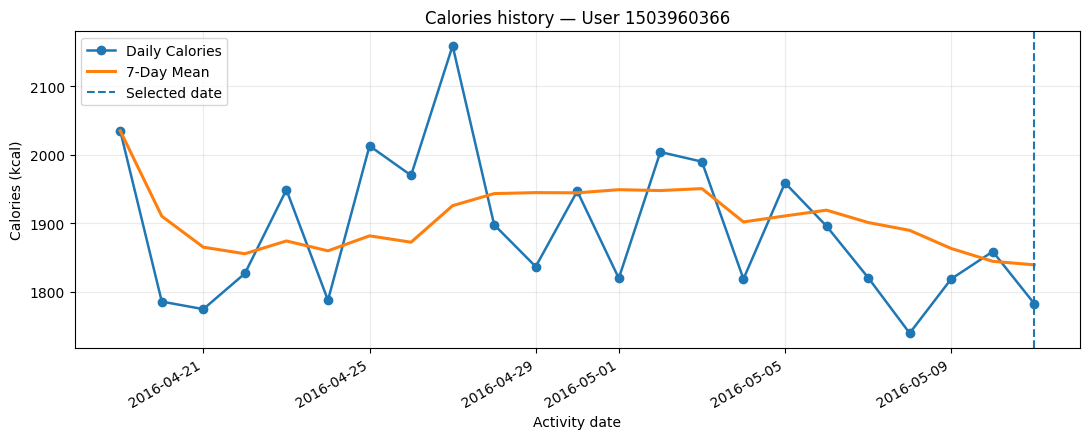


MODULE 11 — USER HISTORY READY
✓ Historical Calories data
✓ 30-day history window
✓ 7-Day Mean trend
✓ Selected-date marker
✓ History statistics
✓ No future observations used


In [43]:
# @title
# ============================================================
# MODULE 11 — USER HISTORY
# ============================================================

print("=" * 70)
print("MODULE 11 — USER HISTORY")
print("=" * 70)


# ------------------------------------------------------------
# HISTORY DATA PREPARATION
# ------------------------------------------------------------

def prepare_history_data(
    user_id,
    activity_date,
    days=30
):
    """
    Prepare historical Calories data for visualization.

    Only observations up to the selected date are included.
    """

    history = get_user_history(
        user_id,
        activity_date,
        days=days
    ).copy()

    if history.empty:
        return history

    history = history.sort_values(
        "ActivityDate"
    ).reset_index(drop=True)

    history["Calories_rolling_7"] = (
        history["Calories"]
        .rolling(
            window=7,
            min_periods=1
        )
        .mean()
    )

    return history


# ------------------------------------------------------------
# HISTORY CHART
# ------------------------------------------------------------

def render_history_chart(
    user_id,
    activity_date,
    days=30
):
    """
    Render the user's recent Calories history.
    """

    history = prepare_history_data(
        user_id,
        activity_date,
        days=days
    )

    if history.empty:

        display(HTML("""
        <div class="ui-status ui-status-warning">
            No historical data available for this user/date.
        </div>
        """))

        return

    selected_date = pd.Timestamp(
        activity_date
    )

    fig, ax = plt.subplots(
        figsize=(11, 4.5)
    )

    ax.plot(
        history["ActivityDate"],
        history["Calories"],
        marker="o",
        linewidth=1.8,
        label="Daily Calories"
    )

    ax.plot(
        history["ActivityDate"],
        history["Calories_rolling_7"],
        linewidth=2.2,
        label="7-Day Mean"
    )

    ax.axvline(
        selected_date,
        linestyle="--",
        linewidth=1.5,
        label="Selected date"
    )

    ax.set_title(
        f"Calories history — User {user_id}"
    )

    ax.set_xlabel(
        "Activity date"
    )

    ax.set_ylabel(
        "Calories (kcal)"
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend()

    fig.autofmt_xdate()

    plt.tight_layout()

    display(fig)

    plt.close(fig)


# ------------------------------------------------------------
# HISTORY SUMMARY
# ------------------------------------------------------------

def render_history_summary(
    user_id,
    activity_date,
    days=30
):
    """
    Render compact statistics for the selected history window.
    """

    history = prepare_history_data(
        user_id,
        activity_date,
        days=days
    )

    if history.empty:
        return

    calories = history["Calories"]

    min_calories = calories.min()
    max_calories = calories.max()
    mean_calories = calories.mean()

    latest_calories = calories.iloc[-1]

    display(HTML(f"""
    <div class="ui-metric-grid">

        <div class="ui-metric">

            <div class="ui-metric-label">
                History window
            </div>

            <div class="ui-metric-value">
                {len(history)} days
            </div>

        </div>


        <div class="ui-metric">

            <div class="ui-metric-label">
                Average Calories
            </div>

            <div class="ui-metric-value">
                {format_kcal(mean_calories)}
            </div>

        </div>


        <div class="ui-metric">

            <div class="ui-metric-label">
                Minimum
            </div>

            <div class="ui-metric-value">
                {format_kcal(min_calories)}
            </div>

        </div>


        <div class="ui-metric">

            <div class="ui-metric-label">
                Maximum
            </div>

            <div class="ui-metric-value">
                {format_kcal(max_calories)}
            </div>

        </div>


        <div class="ui-metric">

            <div class="ui-metric-label">
                Latest Calories
            </div>

            <div class="ui-metric-value">
                {format_kcal(latest_calories)}
            </div>

        </div>

    </div>
    """))


# ------------------------------------------------------------
# HISTORY RENDERER
# ------------------------------------------------------------

def render_history(
    user_id,
    activity_date,
    days=30
):
    """
    Render the complete User History section.
    """

    display(HTML("""
    <div class="ui-section">

        <div class="ui-card">

            <div class="ui-card-title">
                User history
            </div>

            <div class="ui-section-subtitle">
                Recent daily energy expenditure and
                7-day moving average.
            </div>

    """))

    render_history_summary(
        user_id,
        activity_date,
        days=days
    )

    render_history_chart(
        user_id,
        activity_date,
        days=days
    )

    display(HTML("""
            <div class="ui-footnote">
                The history is based only on observations
                available up to the selected activity date.
                The next-day target is not used in this chart.
            </div>

        </div>

    </div>
    """))


# ============================================================
# TEST HISTORY RENDERER
# ============================================================

print()
print("Rendering test user history...")

render_history(
    test_user,
    test_date,
    days=30
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

test_history_data = prepare_history_data(
    test_user,
    test_date,
    days=30
)

if test_history_data.empty:
    raise ValueError(
        "History renderer отримав порожню "
        "історію для тестового observation."
    )

if "Calories" not in test_history_data.columns:
    raise ValueError(
        "History dataset не містить "
        "колонки Calories."
    )

if "Calories_rolling_7" not in test_history_data.columns:
    raise ValueError(
        "Не було створено 7-day rolling mean."
    )

if (
    test_history_data["ActivityDate"]
    > pd.Timestamp(test_date)
).any():
    raise ValueError(
        "History renderer використав "
        "майбутні observations."
    )


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 11 — USER HISTORY READY")
print("=" * 70)

print("✓ Historical Calories data")
print("✓ 30-day history window")
print("✓ 7-Day Mean trend")
print("✓ Selected-date marker")
print("✓ History statistics")
print("✓ No future observations used")
print("=" * 70)

In [44]:
# @title
# ============================================================
# MODULE 12 — MODEL VS BASELINE
# ============================================================

print("=" * 70)
print("MODULE 12 — MODEL VS BASELINE")
print("=" * 70)


# ------------------------------------------------------------
# COMPARISON DATA
# ------------------------------------------------------------

def prepare_baseline_comparison(
    result
):
    """
    Prepare Random Forest and baseline values
    for UI comparison.
    """

    model_value = float(
        result["predicted"]
    )

    baseline_7day = result.get(
        "baseline_7day",
        np.nan
    )

    baseline_user = (
        baseline_user_mean(
            result["user_id"],
            result["activity_date"]
        )
    )

    return {
        "Random Forest": model_value,
        "7-Day Mean": baseline_7day,
        "User Mean": baseline_user,
    }


# ------------------------------------------------------------
# COMPARISON TABLE
# ------------------------------------------------------------

def render_baseline_comparison(
    result,
    validation=False
):
    """
    Render a direct comparison between the final model
    and simple baseline strategies.

    In validation mode, actual next-day Calories
    and absolute errors are also displayed.
    """

    comparison = prepare_baseline_comparison(
        result
    )

    actual = result.get(
        "actual",
        np.nan
    )

    rows_html = ""

    for name, value in comparison.items():

        if pd.isna(value):
            value_text = "—"
        else:
            value_text = format_kcal(
                value
            )

        error_text = "—"

        if (
            validation
            and not pd.isna(actual)
            and not pd.isna(value)
        ):
            error_text = format_kcal(
                abs(value - actual)
            )

        rows_html += f"""
        <tr>
            <td><b>{safe_text(name)}</b></td>
            <td>{value_text}</td>
            {"<td>" + error_text + "</td>" if validation else ""}
        </tr>
        """

    actual_row = ""

    if validation and not pd.isna(actual):

        actual_row = f"""
        <tr>
            <td><b>Actual next-day Calories</b></td>
            <td><b>{format_kcal(actual)}</b></td>
            <td>—</td>
        </tr>
        """

    error_header = (
        "<th>Absolute error</th>"
        if validation
        else ""
    )

    display(HTML(f"""
    <div class="ui-section">

        <div class="ui-card">

            <div class="ui-card-title">
                Model vs baseline
            </div>

            <div class="ui-section-subtitle">
                Comparison of the Random Forest forecast
                with simple historical baselines.
            </div>

            <table class="ui-table">

                <thead>
                    <tr>
                        <th>Method</th>
                        <th>Forecast</th>
                        {error_header}
                    </tr>
                </thead>

                <tbody>
                    {rows_html}
                    {actual_row}
                </tbody>

            </table>

            <div class="ui-footnote">
                Baselines are calculated from historical
                Calories available up to the selected date.
            </div>

        </div>

    </div>
    """))


# ------------------------------------------------------------
# MODEL ADVANTAGE
# ------------------------------------------------------------

def render_model_advantage(
    result,
    validation=False
):
    """
    Render a compact interpretation of the model
    relative to the baseline methods.
    """

    model = result["predicted"]

    baseline_7day = result.get(
        "baseline_7day",
        np.nan
    )

    baseline_user = baseline_user_mean(
        result["user_id"],
        result["activity_date"]
    )

    messages = []

    if not pd.isna(baseline_7day):

        difference = (
            model - baseline_7day
        )

        messages.append(
            f"Random Forest is "
            f"{format_signed_kcal(difference)} "
            f"relative to the 7-Day Mean."
        )

    if not pd.isna(baseline_user):

        difference = (
            model - baseline_user
        )

        messages.append(
            f"Random Forest is "
            f"{format_signed_kcal(difference)} "
            f"relative to the User Mean."
        )

    if validation:

        actual = result.get(
            "actual",
            np.nan
        )

        if not pd.isna(actual):

            model_error = abs(
                model - actual
            )

            messages.append(
                f"Random Forest absolute error: "
                f"{format_kcal(model_error)}."
            )

    if not messages:
        return

    message_html = "<br>".join(
        safe_text(message)
        for message in messages
    )

    display(HTML(f"""
    <div class="ui-status">
        {message_html}
    </div>
    """))


# ============================================================
# TEST — REAL PREDICTION
# ============================================================

print()
print("Rendering model vs baseline...")

render_baseline_comparison(
    test_result_real,
    validation=False
)

render_model_advantage(
    test_result_real,
    validation=False
)


# ------------------------------------------------------------
# TEST — VALIDATION
# ------------------------------------------------------------

print()
print("Rendering validation comparison...")

render_baseline_comparison(
    test_result_demo,
    validation=True
)

render_model_advantage(
    test_result_demo,
    validation=True
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

test_comparison = (
    prepare_baseline_comparison(
        test_result_real
    )
)

required_methods = {
    "Random Forest",
    "7-Day Mean",
    "User Mean",
}

if not required_methods.issubset(
    test_comparison.keys()
):
    raise ValueError(
        "Не всі baseline methods "
        "присутні в comparison."
    )

if pd.isna(
    test_comparison["Random Forest"]
):
    raise ValueError(
        "Random Forest prediction "
        "відсутній."
    )

if pd.isna(
    test_comparison["7-Day Mean"]
):
    raise ValueError(
        "7-Day Mean baseline "
        "відсутній."
    )

if pd.isna(
    test_comparison["User Mean"]
):
    raise ValueError(
        "User Mean baseline "
        "відсутній."
    )


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 12 — MODEL VS BASELINE READY")
print("=" * 70)

print("✓ Random Forest comparison")
print("✓ 7-Day Mean comparison")
print("✓ User Mean comparison")
print("✓ Validation error comparison")
print("✓ Model advantage summary")
print("=" * 70)

MODULE 12 — MODEL VS BASELINE

Rendering model vs baseline...


Method,Forecast
Random Forest,"1,766 kcal"
7-Day Mean,"1,840 kcal"
User Mean,"1,891 kcal"



Rendering validation comparison...


Method,Forecast,Absolute error
Random Forest,"1,766 kcal","1,766 kcal"
7-Day Mean,"1,840 kcal","1,840 kcal"
User Mean,"1,891 kcal","1,891 kcal"
Actual next-day Calories,0 kcal,—



MODULE 12 — MODEL VS BASELINE READY
✓ Random Forest comparison
✓ 7-Day Mean comparison
✓ User Mean comparison
✓ Validation error comparison
✓ Model advantage summary


In [45]:
# @title
# ============================================================
# MODULE 13 — SHAP RENDERER
# ============================================================

print("=" * 70)
print("MODULE 13 — SHAP RENDERER")
print("=" * 70)


# ------------------------------------------------------------
# FEATURE NAME FORMATTER
# ------------------------------------------------------------

def format_feature_name(
    feature_name
):
    """
    Convert technical feature names into a more readable
    presentation format.
    """

    name = str(
        feature_name
    )

    replacements = {
        "_rolling_mean_7": " — 7-day mean",
        "_rolling_mean_3": " — 3-day mean",
        "_rolling_std_7": " — 7-day std",
        "_rolling_std_3": " — 3-day std",
        "_lag_1": " — previous day",
        "_lag_2": " — 2 days ago",
        "_lag_3": " — 3 days ago",
        "_lag_7": " — 7 days ago",
    }

    for suffix, replacement in replacements.items():

        if name.endswith(suffix):

            base = name[
                : -len(suffix)
            ]

            return (
                base
                + replacement
            )

    return name


# ------------------------------------------------------------
# SHAP FACTOR CARD
# ------------------------------------------------------------

def render_shap_factor(
    row
):
    """
    Render one local SHAP factor.
    """

    feature = format_feature_name(
        row["feature"]
    )

    shap_value = float(
        row["shap_value"]
    )

    feature_value = row["value"]

    if shap_value > 0:

        direction = (
            "Increases prediction"
        )

        status_class = (
            "ui-status-success"
        )

    else:

        direction = (
            "Decreases prediction"
        )

        status_class = (
            "ui-status-warning"
        )

    display_value = (
        format_kcal(feature_value)
        if "Calories" in str(row["feature"])
        else f"{feature_value:,.2f}"
        if isinstance(
            feature_value,
            (int, float, np.integer, np.floating)
        )
        else safe_text(feature_value)
    )

    display(
        HTML(f"""
        <div class="ui-factor">

            <div>
                <div class="ui-factor-name">
                    {safe_text(feature)}
                </div>

                <div class="ui-footnote">
                    Value: {display_value}
                </div>
            </div>

            <div class="ui-factor-value">
                {shap_value:+.2f} kcal
                <br>
                <span class="{status_class}">
                    {safe_text(direction)}
                </span>
            </div>

        </div>
        """)
    )


# ------------------------------------------------------------
# TOP FACTORS
# ------------------------------------------------------------

def render_top_shap_factors(
    shap_summary
):
    """
    Render the strongest local SHAP factors.
    """

    if not shap_summary.get(
        "available",
        False
    ):

        display(HTML("""
        <div class="ui-status ui-status-warning">
            SHAP explanation is currently unavailable.
        </div>
        """))

        return

    factors = shap_summary.get(
        "top_factors"
    )

    if factors is None or factors.empty:

        display(HTML("""
        <div class="ui-status ui-status-warning">
            No SHAP factors available for this prediction.
        </div>
        """))

        return

    for _, row in factors.iterrows():

        render_shap_factor(
            row
        )


# ------------------------------------------------------------
# POSITIVE / NEGATIVE SUMMARY
# ------------------------------------------------------------

def render_shap_direction_summary(
    shap_summary
):
    """
    Render compact positive and negative SHAP summaries.
    """

    if not shap_summary.get(
        "available",
        False
    ):
        return

    positive = shap_summary.get(
        "positive"
    )

    negative = shap_summary.get(
        "negative"
    )

    positive_text = (
        "No positive factors."
        if positive is None or positive.empty
        else ", ".join(
            format_feature_name(
                feature
            )
            for feature in positive[
                "feature"
            ].head(3)
        )
    )

    negative_text = (
        "No negative factors."
        if negative is None or negative.empty
        else ", ".join(
            format_feature_name(
                feature
            )
            for feature in negative[
                "feature"
            ].head(3)
        )
    )

    display(HTML(f"""
    <div class="ui-two-columns">

        <div class="ui-column">

            <div class="ui-card">

                <div class="ui-card-title">
                    Factors increasing prediction
                </div>

                <div class="ui-card-note">
                    {safe_text(positive_text)}
                </div>

            </div>

        </div>


        <div class="ui-column">

            <div class="ui-card">

                <div class="ui-card-title">
                    Factors decreasing prediction
                </div>

                <div class="ui-card-note">
                    {safe_text(negative_text)}
                </div>

            </div>

        </div>

    </div>
    """))


# ------------------------------------------------------------
# COMPLETE SHAP SECTION
# ------------------------------------------------------------

def render_shap_section(
    modeling_row,
    top_n=SHAP_TOP_N
):
    """
    Render the complete local SHAP explanation section.
    """

    shap_summary = get_shap_summary(
        modeling_row,
        top_n=top_n
    )

    display(HTML("""
    <div class="ui-section">

        <div class="ui-card">

            <div class="ui-card-title">
                Main factors influencing the forecast
            </div>

            <div class="ui-section-subtitle">
                Local SHAP explanation for the selected
                user and observation date.
            </div>

    """))

    render_top_shap_factors(
        shap_summary
    )

    display(HTML("""
        </div>

    </div>
    """))

    render_shap_direction_summary(
        shap_summary
    )

    return shap_summary


# ============================================================
# TEST SHAP RENDERER
# ============================================================

print()
print("Rendering test SHAP explanation...")

test_shap_rendered = render_shap_section(
    test_modeling_row,
    top_n=SHAP_TOP_N
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if SHAP_AVAILABLE:

    if not test_shap_rendered["available"]:
        raise ValueError(
            "SHAP renderer не отримав "
            "доступного SHAP summary."
        )

    if (
        test_shap_rendered["top_factors"]
        is None
    ):
        raise ValueError(
            "SHAP renderer не отримав "
            "top factors."
        )

    if (
        len(
            test_shap_rendered["top_factors"]
        )
        > SHAP_TOP_N
    ):
        raise ValueError(
            "SHAP renderer показує "
            "більше факторів, ніж дозволено."
        )


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 13 — SHAP RENDERER READY")
print("=" * 70)

print("✓ Readable feature names")
print("✓ Local SHAP factor cards")
print("✓ Positive / negative direction")
print("✓ Top SHAP factors")
print("✓ SHAP direction summary")
print("✓ UI-ready explanation")
print("=" * 70)

MODULE 13 — SHAP RENDERER

Rendering test SHAP explanation...



MODULE 13 — SHAP RENDERER READY
✓ Readable feature names
✓ Local SHAP factor cards
✓ Positive / negative direction
✓ Top SHAP factors
✓ SHAP direction summary
✓ UI-ready explanation


In [46]:
# @title
# ============================================================
# MODULE 14 — DEMO & VALIDATION
# ============================================================

print("=" * 70)
print("MODULE 14 — DEMO & VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# VALIDATION RESULT PREPARATION
# ------------------------------------------------------------

def prepare_validation_result(
    result
):
    """
    Prepare actual target and prediction errors
    for Demo & Validation mode.
    """

    predicted = float(
        result["predicted"]
    )

    actual = result.get(
        "actual",
        np.nan
    )

    if pd.isna(actual):

        return {
            "available": False,
            "predicted": predicted,
            "actual": np.nan,
            "absolute_error": np.nan,
            "signed_error": np.nan,
        }

    actual = float(actual)

    return {
        "available": True,
        "predicted": predicted,
        "actual": actual,
        "absolute_error": abs(
            predicted - actual
        ),
        "signed_error": (
            predicted - actual
        ),
    }


# ------------------------------------------------------------
# VALIDATION STATUS
# ------------------------------------------------------------

def get_validation_status(
    absolute_error
):
    """
    Convert prediction error into a simple
    human-readable validation status.

    Thresholds are intended only for UI interpretation,
    not for scientific evaluation.
    """

    if pd.isna(absolute_error):
        return (
            "Unavailable",
            "ui-status-warning"
        )

    if absolute_error <= 100:
        return (
            "Very close to actual value",
            "ui-status-success"
        )

    if absolute_error <= 250:
        return (
            "Reasonably close to actual value",
            "ui-status-success"
        )

    if absolute_error <= 500:
        return (
            "Moderate prediction error",
            "ui-status-warning"
        )

    return (
        "Large prediction error",
        "ui-status-error"
    )


# ------------------------------------------------------------
# VALIDATION CARD
# ------------------------------------------------------------

def render_validation_card(
    result
):
    """
    Render the actual result and prediction error.

    This section must only be used in
    Demo & Validation mode.
    """

    validation = prepare_validation_result(
        result
    )

    if not validation["available"]:

        display(HTML("""
        <div class="ui-status ui-status-warning">
            Actual next-day Calories are not available
            for this observation. Validation cannot be performed.
        </div>
        """))

        return

    status_text, status_class = (
        get_validation_status(
            validation["absolute_error"]
        )
    )

    display(HTML(f"""
    <div class="ui-section">

        <div class="ui-card">

            <div class="ui-card-title">
                Demo &amp; Validation
            </div>

            <div class="ui-section-subtitle">
                Comparison with the known next-day target.
            </div>


            <div class="ui-metric-grid">

                <div class="ui-metric">

                    <div class="ui-metric-label">
                        Actual next-day Calories
                    </div>

                    <div class="ui-metric-value">
                        {format_kcal(
                            validation["actual"]
                        )}
                    </div>

                </div>


                <div class="ui-metric">

                    <div class="ui-metric-label">
                        Random Forest prediction
                    </div>

                    <div class="ui-metric-value">
                        {format_kcal(
                            validation["predicted"]
                        )}
                    </div>

                </div>


                <div class="ui-metric">

                    <div class="ui-metric-label">
                        Absolute error
                    </div>

                    <div class="ui-metric-value">
                        {format_kcal(
                            validation["absolute_error"]
                        )}
                    </div>

                </div>


                <div class="ui-metric">

                    <div class="ui-metric-label">
                        Signed error
                    </div>

                    <div class="ui-metric-value">
                        {format_signed_kcal(
                            validation["signed_error"]
                        )}
                    </div>

                </div>

            </div>


            <div class="ui-status {status_class}">
                <b>{safe_text(status_text)}</b>
            </div>


            <div class="ui-footnote">
                Signed error = prediction − actual.
                Positive values indicate overestimation;
                negative values indicate underestimation.
            </div>

        </div>

    </div>
    """))


# ------------------------------------------------------------
# BASELINE VALIDATION SUMMARY
# ------------------------------------------------------------

def render_validation_baseline_result(
    result
):
    """
    Compare Random Forest error with baseline errors
    when the actual target is available.
    """

    validation = prepare_validation_result(
        result
    )

    if not validation["available"]:
        return

    actual = validation["actual"]

    model_error = validation[
        "absolute_error"
    ]

    baseline_7day = result.get(
        "baseline_7day",
        np.nan
    )

    baseline_user = baseline_user_mean(
        result["user_id"],
        result["activity_date"]
    )

    errors = {
        "Random Forest": model_error,
        "7-Day Mean": (
            abs(
                baseline_7day - actual
            )
            if not pd.isna(baseline_7day)
            else np.nan
        ),
        "User Mean": (
            abs(
                baseline_user - actual
            )
            if not pd.isna(baseline_user)
            else np.nan
        ),
    }

    valid_errors = {
        name: value
        for name, value in errors.items()
        if not pd.isna(value)
    }

    if not valid_errors:
        return

    best_method = min(
        valid_errors,
        key=valid_errors.get
    )

    rows_html = ""

    for name, error in errors.items():

        error_text = (
            format_kcal(error)
            if not pd.isna(error)
            else "—"
        )

        marker = (
            " ✓"
            if name == best_method
            else ""
        )

        rows_html += f"""
        <tr>
            <td>
                <b>{safe_text(name)}</b>{marker}
            </td>
            <td>{error_text}</td>
        </tr>
        """

    display(HTML(f"""
    <div class="ui-section">

        <div class="ui-card">

            <div class="ui-card-title">
                Validation error comparison
            </div>

            <table class="ui-table">

                <thead>
                    <tr>
                        <th>Method</th>
                        <th>Absolute error</th>
                    </tr>
                </thead>

                <tbody>
                    {rows_html}
                </tbody>

            </table>

            <div class="ui-card-note">
                Best result for this observation:
                <b>{safe_text(best_method)}</b>
            </div>

        </div>

    </div>
    """))


# ============================================================
# TEST — VALIDATION MODE
# ============================================================

print()
print("Rendering Demo & Validation...")

render_validation_card(
    test_result_demo
)

render_validation_baseline_result(
    test_result_demo
)


# ------------------------------------------------------------
# REAL MODE SAFETY CHECK
# ------------------------------------------------------------

print()
print("Checking Real Prediction separation...")

real_validation = prepare_validation_result(
    test_result_real
)

if (
    real_validation["available"]
    and "actual" in test_result_real
):
    print(
        "✓ Actual value is available internally "
        "but is not rendered by Real Prediction."
    )
else:
    print(
        "✓ Real Prediction contains no rendered validation target."
    )


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

test_validation = prepare_validation_result(
    test_result_demo
)

if not test_validation["available"]:
    raise ValueError(
        "Demo result не містить actual "
        "для validation test."
    )

if not np.isfinite(
    test_validation["predicted"]
):
    raise ValueError(
        "Validation prediction має "
        "некоректне значення."
    )

if not np.isfinite(
    test_validation["actual"]
):
    raise ValueError(
        "Validation actual має "
        "некоректне значення."
    )

expected_error = abs(
    test_validation["predicted"]
    - test_validation["actual"]
)

if not np.isclose(
    test_validation["absolute_error"],
    expected_error
):
    raise ValueError(
        "Absolute error розраховано "
        "некоректно."
    )


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 14 — DEMO & VALIDATION READY")
print("=" * 70)

print("✓ Actual target display")
print("✓ Prediction vs actual")
print("✓ Absolute error")
print("✓ Signed error")
print("✓ Validation status")
print("✓ Baseline error comparison")
print("✓ Real Prediction / Validation separation")
print("=" * 70)

MODULE 14 — DEMO & VALIDATION

Rendering Demo & Validation...


Method,Absolute error
Random Forest ✓,"1,766 kcal"
7-Day Mean,"1,840 kcal"
User Mean,"1,891 kcal"



Checking Real Prediction separation...
✓ Actual value is available internally but is not rendered by Real Prediction.

MODULE 14 — DEMO & VALIDATION READY
✓ Actual target display
✓ Prediction vs actual
✓ Absolute error
✓ Signed error
✓ Validation status
✓ Baseline error comparison
✓ Real Prediction / Validation separation


In [47]:
# @title
# ============================================================
# MODULE 15 — FINAL DASHBOARD ASSEMBLY
# ============================================================

print("=" * 70)
print("MODULE 15 — FINAL DASHBOARD ASSEMBLY")
print("=" * 70)


# ------------------------------------------------------------
# DASHBOARD HEADER
# ------------------------------------------------------------

def render_dashboard_header(
    user_id,
    activity_date,
    mode
):
    """
    Render the dashboard header and current prediction mode.
    """

    if mode == "real":

        mode_label = "Real Prediction"

    else:

        mode_label = "Demo & Validation"

    display(HTML(f"""
    <div class="ui-page">

        <div class="ui-header">

            <div class="ui-title">
                Energy Forecast Dashboard
            </div>

            <div class="ui-subtitle">
                Intelligent next-day energy expenditure
                prediction based on Fitbit activity history.
            </div>

            <div style="margin-top: 13px;">

                <span class="ui-mode">
                    {safe_text(mode_label)}
                </span>

                &nbsp;

                <span class="ui-mode">
                    User: {safe_text(user_id)}
                </span>

                &nbsp;

                <span class="ui-mode">
                    Date: {pd.Timestamp(activity_date).date()}
                </span>

            </div>

        </div>

    </div>
    """))


# ------------------------------------------------------------
# DASHBOARD CONTENT OUTPUT
# ------------------------------------------------------------

dashboard_output = widgets.Output(
    layout=widgets.Layout(
        width="100%"
    )
)


# ------------------------------------------------------------
# MAIN DASHBOARD RENDERER
# ------------------------------------------------------------

def render_dashboard(
    user_id,
    activity_date,
    mode
):
    """
    Render the complete dashboard for the selected
    user, date and prediction mode.
    """

    with dashboard_output:

        clear_output(
            wait=True
        )

        try:

            # ------------------------------------------------
            # HEADER
            # ------------------------------------------------

            render_dashboard_header(
                user_id,
                activity_date,
                mode
            )


            # ------------------------------------------------
            # PREDICTION
            # ------------------------------------------------

            validation = (
                mode == "demo"
            )

            result = build_prediction_result(
                user_id,
                activity_date,
                validation=validation
            )


            # ------------------------------------------------
            # FORECAST
            # ------------------------------------------------

            render_forecast_card(
                result
            )


            # ------------------------------------------------
            # MODEL VS BASELINE
            # ------------------------------------------------

            render_baseline_comparison(
                result,
                validation=validation
            )


            render_model_advantage(
                result,
                validation=validation
            )


            # ------------------------------------------------
            # SHAP
            # ------------------------------------------------

            render_shap_section(
                result["modeling_row"],
                top_n=SHAP_TOP_N
            )


            # ------------------------------------------------
            # USER HISTORY
            # ------------------------------------------------

            render_history(
                user_id,
                activity_date,
                days=HISTORY_DAYS
            )


            # ------------------------------------------------
            # DEMO / VALIDATION
            # ------------------------------------------------

            if validation:

                render_validation_card(
                    result
                )

                render_validation_baseline_result(
                    result
                )


            # ------------------------------------------------
            # FINAL STATUS
            # ------------------------------------------------

            display(HTML("""
            <div class="ui-section">

                <div class="ui-status ui-status-success">

                    ✓ Dashboard updated successfully.

                </div>

            </div>
            """))


        except Exception as error:

            display(HTML(f"""
            <div class="ui-page">

                <div class="ui-error">

                    <b>Unable to generate dashboard.</b>

                    <br><br>

                    {safe_text(error)}

                </div>

            </div>
            """))


# ------------------------------------------------------------
# BUTTON CALLBACK
# ------------------------------------------------------------

def on_forecast_button_click(
    button
):
    """
    Handle the Forecast button.
    """

    selected_user = user_selector.value
    selected_date = date_selector.value
    selected_mode = mode_selector.value

    if selected_date is None:

        with dashboard_output:

            clear_output(
                wait=True
            )

            display(HTML("""
            <div class="ui-error">
                Please select a valid activity date.
            </div>
            """))

        return


    # Disable button while processing.
    forecast_button.disabled = True

    original_description = (
        forecast_button.description
    )

    forecast_button.description = (
        "Generating..."
    )

    try:

        render_dashboard(
            selected_user,
            selected_date,
            selected_mode
        )

    finally:

        forecast_button.description = (
            original_description
        )

        forecast_button.disabled = False


# ------------------------------------------------------------
# CONNECT BUTTON
# ------------------------------------------------------------

forecast_button.on_click(
    on_forecast_button_click
)


# ------------------------------------------------------------
# DASHBOARD INTRO
# ------------------------------------------------------------

display(HTML("""
<div class="ui-page">

    <div class="ui-header">

        <div class="ui-title">
            Energy Forecast Dashboard
        </div>

        <div class="ui-subtitle">
            Select a user, observation date and prediction mode,
            then generate a next-day energy expenditure forecast.
        </div>

    </div>

</div>
"""))


# ------------------------------------------------------------
# DISPLAY CONTROLS
# ------------------------------------------------------------

display(
    controls_box
)


# ------------------------------------------------------------
# INITIAL EMPTY STATE
# ------------------------------------------------------------

with dashboard_output:

    display(HTML("""
    <div class="ui-page">

        <div class="ui-status ui-status-warning">

            Select the required settings above and click
            <b>Forecast next day</b> to generate the dashboard.

        </div>

    </div>
    """))


display(
    dashboard_output
)


# ============================================================
# FINAL DASHBOARD VALIDATION
# ============================================================

print()
print("Testing dashboard assembly...")

# Use the same test observation that was used
# throughout Modules 04–14.
render_dashboard(
    test_user,
    test_date,
    "real"
)


# ------------------------------------------------------------
# CHECK REQUIRED COMPONENTS
# ------------------------------------------------------------

required_dashboard_functions = [
    render_dashboard_header,
    render_dashboard,
    on_forecast_button_click,
]

for function in required_dashboard_functions:

    if not callable(function):

        raise TypeError(
            f"Dashboard component "
            f"{function} is not callable."
        )


# ------------------------------------------------------------
# FINAL MODULE STATUS
# ------------------------------------------------------------

print()
print("=" * 70)
print("MODULE 15 — FINAL DASHBOARD READY")
print("=" * 70)

print("✓ Dashboard header")
print("✓ User / date / mode controls")
print("✓ Next-day forecast")
print("✓ Model vs baseline")
print("✓ Local SHAP factors")
print("✓ User history")
print("✓ Demo & Validation")
print("✓ Error handling")
print("✓ Interactive Forecast button")
print("✓ Real Prediction / Validation separation")
print("=" * 70)

MODULE 15 — FINAL DASHBOARD ASSEMBLY


Output(layout=Layout(width='100%'))


Testing dashboard assembly...

MODULE 15 — FINAL DASHBOARD READY
✓ Dashboard header
✓ User / date / mode controls
✓ Next-day forecast
✓ Model vs baseline
✓ Local SHAP factors
✓ User history
✓ Demo & Validation
✓ Error handling
✓ Interactive Forecast button
✓ Real Prediction / Validation separation


In [48]:
# @title
# ============================================================
# MODULE 15.1 — FINAL UI COMPOSITION
# ============================================================

print("=" * 70)
print("MODULE 15.1 — FINAL UI COMPOSITION")
print("=" * 70)


# ------------------------------------------------------------
# INLINE UI HELPERS
# ------------------------------------------------------------

def ui_html(
    content,
    padding="16px",
    margin="0 0 12px 0",
    background="#ffffff",
    border="#d9dde3",
    radius="14px",
):
    """
    Create a reliable HTML card using inline styles.
    """

    return widgets.HTML(
        value=f"""
        <div style="
            box-sizing:border-box;
            width:100%;
            padding:{padding};
            margin:{margin};
            background:{background};
            border:1px solid {border};
            border-radius:{radius};
            font-family:Arial,sans-serif;
            color:#20242a;
        ">
            {content}
        </div>
        """
    )


def ui_title(
    title,
    subtitle=None
):
    """
    Dashboard section title.
    """

    subtitle_html = ""

    if subtitle:
        subtitle_html = f"""
        <div style="
            margin-top:5px;
            font-size:13px;
            color:#68707a;
        ">
            {safe_text(subtitle)}
        </div>
        """

    return widgets.HTML(
        value=f"""
        <div style="
            margin:16px 0 8px 0;
            font-family:Arial,sans-serif;
        ">
            <div style="
                font-size:19px;
                font-weight:700;
                color:#20242a;
            ">
                {safe_text(title)}
            </div>
            {subtitle_html}
        </div>
        """
    )


def ui_metric(
    label,
    value,
    note=""
):
    """
    Single dashboard metric.
    """

    note_html = ""

    if note:
        note_html = f"""
        <div style="
            margin-top:5px;
            font-size:12px;
            color:#68707a;
        ">
            {safe_text(note)}
        </div>
        """

    return widgets.HTML(
        value=f"""
        <div style="
            box-sizing:border-box;
            flex:1 1 180px;
            min-width:170px;
            padding:16px;
            background:#f4f5f7;
            border-radius:11px;
        ">

            <div style="
                font-size:12px;
                color:#68707a;
                margin-bottom:6px;
            ">
                {safe_text(label)}
            </div>

            <div style="
                font-size:23px;
                font-weight:700;
                line-height:1.2;
                color:#20242a;
            ">
                {safe_text(value)}
            </div>

            {note_html}

        </div>
        """
    )


def ui_metric_row(
    metrics
):
    """
    Horizontal responsive metric row.
    """

    return widgets.HBox(
        metrics,
        layout=widgets.Layout(
            width="100%",
            display="flex",
            flex_flow="row wrap",
            gap="10px",
            margin="0 0 12px 0",
        )
    )


# ------------------------------------------------------------
# FORECAST CARD
# ------------------------------------------------------------

def build_forecast_widget(
    result
):
    """
    Build the main forecast card as a widget.
    """

    predicted = float(
        result["predicted"]
    )

    baseline = result.get(
        "baseline_7day",
        np.nan
    )

    current = result.get(
        "current_calories",
        np.nan
    )

    difference = (
        predicted - baseline
        if not pd.isna(baseline)
        else np.nan
    )

    difference_text = (
        format_signed_kcal(difference)
        if not pd.isna(difference)
        else "—"
    )

    baseline_text = (
        format_kcal(baseline)
        if not pd.isna(baseline)
        else "—"
    )

    current_text = (
        format_kcal(current)
        if not pd.isna(current)
        else "—"
    )

    return ui_html(
        f"""
        <div style="
            font-size:18px;
            font-weight:700;
            margin-bottom:5px;
        ">
            Next-day forecast
        </div>

        <div style="
            font-size:13px;
            color:#68707a;
            margin-bottom:16px;
        ">
            Random Forest — All Features
        </div>

        <div style="
            padding:24px;
            background:#f4f5f7;
            border-radius:13px;
            text-align:center;
            margin-bottom:14px;
        ">

            <div style="
                font-size:13px;
                color:#68707a;
                margin-bottom:5px;
            ">
                Predicted energy expenditure
            </div>

            <div style="
                font-size:40px;
                font-weight:700;
                line-height:1.1;
            ">
                {format_kcal(predicted)}
            </div>

        </div>
        """,
        padding="20px",
    )


# ------------------------------------------------------------
# MODEL VS BASELINE CARD
# ------------------------------------------------------------

def build_baseline_widget(
    result
):
    """
    Build model vs baseline comparison.
    """

    comparison = prepare_baseline_comparison(
        result
    )

    rf = comparison["Random Forest"]
    seven_day = comparison["7-Day Mean"]
    user_mean = comparison["User Mean"]

    return ui_html(
        f"""
        <div style="
            font-size:18px;
            font-weight:700;
            margin-bottom:14px;
        ">
            Model vs baseline
        </div>

        <div style="
            display:grid;
            grid-template-columns:1fr 1fr 1fr;
            gap:10px;
        ">

            <div style="
                padding:14px;
                background:#f4f5f7;
                border-radius:10px;
            ">
                <div style="font-size:12px;color:#68707a;">
                    Random Forest
                </div>
                <div style="font-size:21px;font-weight:700;">
                    {format_kcal(rf)}
                </div>
            </div>

            <div style="
                padding:14px;
                background:#f4f5f7;
                border-radius:10px;
            ">
                <div style="font-size:12px;color:#68707a;">
                    7-Day Mean
                </div>
                <div style="font-size:21px;font-weight:700;">
                    {format_kcal(seven_day)}
                </div>
            </div>

            <div style="
                padding:14px;
                background:#f4f5f7;
                border-radius:10px;
            ">
                <div style="font-size:12px;color:#68707a;">
                    User Mean
                </div>
                <div style="font-size:21px;font-weight:700;">
                    {format_kcal(user_mean)}
                </div>
            </div>

        </div>
        """
    )


# ------------------------------------------------------------
# SHAP CARD
# ------------------------------------------------------------

def build_shap_widget(
    modeling_row,
    top_n=5
):
    """
    Build compact local SHAP explanation.
    """

    shap_summary = get_shap_summary(
        modeling_row,
        top_n=top_n
    )

    if not shap_summary.get(
        "available",
        False
    ):

        return ui_html(
            """
            <div style="
                font-size:18px;
                font-weight:700;
                margin-bottom:8px;
            ">
                Main factors influencing the forecast
            </div>

            <div style="
                padding:12px;
                background:#fff8e8;
                border:1px solid #ead39a;
                border-radius:9px;
                font-size:13px;
            ">
                SHAP explanation is unavailable.
            </div>
            """
        )

    factors = shap_summary[
        "top_factors"
    ]

    factor_blocks = []

    for _, row in factors.head(
        top_n
    ).iterrows():

        feature = format_feature_name(
            row["feature"]
        )

        shap_value = float(
            row["shap_value"]
        )

        if shap_value >= 0:

            direction = "↑ increases prediction"

        else:

            direction = "↓ decreases prediction"

        factor_blocks.append(
            f"""
            <div style="
                display:flex;
                justify-content:space-between;
                align-items:center;
                gap:12px;
                padding:11px 12px;
                margin-bottom:7px;
                background:#f4f5f7;
                border-radius:9px;
            ">

                <div style="
                    font-size:13px;
                    font-weight:600;
                    overflow-wrap:anywhere;
                ">
                    {safe_text(feature)}

                    <div style="
                        margin-top:3px;
                        font-size:11px;
                        font-weight:400;
                        color:#68707a;
                    ">
                        {safe_text(direction)}
                    </div>
                </div>

                <div style="
                    font-size:13px;
                    font-weight:700;
                    white-space:nowrap;
                ">
                    {shap_value:+.2f} kcal
                </div>

            </div>
            """
        )

    return ui_html(
        f"""
        <div style="
            font-size:18px;
            font-weight:700;
            margin-bottom:5px;
        ">
            Main factors influencing the forecast
        </div>

        <div style="
            font-size:13px;
            color:#68707a;
            margin-bottom:13px;
        ">
            Local SHAP explanation
        </div>

        {"".join(factor_blocks)}
        """
    )


# ------------------------------------------------------------
# HISTORY CARD
# ------------------------------------------------------------

def build_history_widget(
    user_id,
    activity_date
):
    """
    Build a dashboard history section.
    """

    history = prepare_history_data(
        user_id,
        activity_date,
        days=HISTORY_DAYS
    )

    if history.empty:

        return widgets.VBox([
            ui_title(
                "User history",
                "No historical observations available."
            )
        ])

    calories = history[
        "Calories"
    ]

    summary = ui_metric_row([
        ui_metric(
            "History window",
            f"{len(history)} days"
        ),
        ui_metric(
            "Average Calories",
            format_kcal(calories.mean())
        ),
        ui_metric(
            "Minimum",
            format_kcal(calories.min())
        ),
        ui_metric(
            "Maximum",
            format_kcal(calories.max())
        ),
    ])

    chart_output = widgets.Output(
        layout=widgets.Layout(
            width="100%"
        )
    )

    with chart_output:

        render_history_chart(
            user_id,
            activity_date,
            days=HISTORY_DAYS
        )

    return widgets.VBox([
        ui_title(
            "User history",
            "Recent daily energy expenditure and 7-day moving average."
        ),
        summary,
        chart_output,
        widgets.HTML(
            value="""
            <div style="
                font-size:12px;
                color:#68707a;
                margin:4px 0 16px 0;
            ">
                Only observations available up to the selected
                activity date are shown.
            </div>
            """
        ),
    ])


# ------------------------------------------------------------
# VALIDATION CARD
# ------------------------------------------------------------

def build_validation_widget(
    result
):
    """
    Build validation section for Demo mode.
    """

    validation = prepare_validation_result(
        result
    )

    if not validation["available"]:

        return ui_html(
            """
            <div style="
                font-size:18px;
                font-weight:700;
                margin-bottom:10px;
            ">
                Demo &amp; Validation
            </div>

            <div style="
                padding:13px;
                background:#fff8e8;
                border:1px solid #ead39a;
                border-radius:9px;
            ">
                Actual next-day Calories are unavailable.
            </div>
            """
        )

    return ui_html(
        f"""
        <div style="
            font-size:18px;
            font-weight:700;
            margin-bottom:14px;
        ">
            Demo &amp; Validation
        </div>

        <div style="
            display:grid;
            grid-template-columns:1fr 1fr 1fr;
            gap:10px;
        ">

            <div style="
                padding:14px;
                background:#f4f5f7;
                border-radius:10px;
            ">
                <div style="font-size:12px;color:#68707a;">
                    Actual
                </div>
                <div style="font-size:21px;font-weight:700;">
                    {format_kcal(validation["actual"])}
                </div>
            </div>

            <div style="
                padding:14px;
                background:#f4f5f7;
                border-radius:10px;
            ">
                <div style="font-size:12px;color:#68707a;">
                    Prediction
                </div>
                <div style="font-size:21px;font-weight:700;">
                    {format_kcal(validation["predicted"])}
                </div>
            </div>

            <div style="
                padding:14px;
                background:#fff8e8;
                border-radius:10px;
            ">
                <div style="font-size:12px;color:#68707a;">
                    Absolute error
                </div>
                <div style="font-size:21px;font-weight:700;">
                    {format_kcal(validation["absolute_error"])}
                </div>
            </div>

        </div>

        <div style="
            margin-top:12px;
            padding:11px 13px;
            background:#f4f5f7;
            border-radius:9px;
            font-size:13px;
        ">
            Signed error:
            <b>
                {format_signed_kcal(validation["signed_error"])}
            </b>

            <span style="color:#68707a;">
                &nbsp; (prediction − actual)
            </span>
        </div>
        """
    )


# ============================================================
# FINAL DASHBOARD RENDERER
# ============================================================

def render_final_dashboard(
    user_id,
    activity_date,
    mode
):
    """
    Render the complete dashboard using real widgets.
    """

    validation = (
        mode == "demo"
    )

    result = build_prediction_result(
        user_id,
        activity_date,
        validation=validation
    )

    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    mode_text = (
        "Real Prediction"
        if mode == "real"
        else "Demo & Validation"
    )

    header = ui_html(
        f"""
        <div style="
            font-size:28px;
            font-weight:700;
            line-height:1.2;
        ">
            Energy Forecast Dashboard
        </div>

        <div style="
            margin-top:7px;
            font-size:14px;
            color:#68707a;
        ">
            Intelligent next-day energy expenditure prediction
            based on Fitbit activity history.
        </div>

        <div style="
            margin-top:13px;
            font-size:12px;
        ">
            <span style="
                display:inline-block;
                padding:6px 10px;
                background:#f4f5f7;
                border:1px solid #d9dde3;
                border-radius:8px;
            ">
                {safe_text(mode_text)}
            </span>

            <span style="
                display:inline-block;
                padding:6px 10px;
                margin-left:6px;
                background:#f4f5f7;
                border:1px solid #d9dde3;
                border-radius:8px;
            ">
                User {safe_text(user_id)}
            </span>

            <span style="
                display:inline-block;
                padding:6px 10px;
                margin-left:6px;
                background:#f4f5f7;
                border:1px solid #d9dde3;
                border-radius:8px;
            ">
                {pd.Timestamp(activity_date).date()}
            </span>
        </div>
        """
    )

    # --------------------------------------------------------
    # FORECAST
    # --------------------------------------------------------

    forecast = build_forecast_widget(
        result
    )

    # --------------------------------------------------------
    # MODEL / BASELINE + SHAP
    # --------------------------------------------------------

    baseline = build_baseline_widget(
        result
    )

    shap = build_shap_widget(
        result["modeling_row"],
        top_n=5
    )

    analysis_row = widgets.HBox(
        [
            widgets.VBox(
                [baseline],
                layout=widgets.Layout(
                    width="50%"
                )
            ),
            widgets.VBox(
                [shap],
                layout=widgets.Layout(
                    width="50%"
                )
            ),
        ],
        layout=widgets.Layout(
            width="100%",
            display="flex",
            flex_flow="row wrap",
            gap="12px",
        )
    )

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history = build_history_widget(
        user_id,
        activity_date
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    validation_widgets = []

    if validation:

        validation_widgets = [
            ui_title(
                "Validation",
                "Shown only in Demo & Validation mode."
            ),
            build_validation_widget(
                result
            ),
        ]

    # --------------------------------------------------------
    # COMPLETE PAGE
    # --------------------------------------------------------

    page = widgets.VBox(
        [
            header,
            forecast,
            analysis_row,
            history,
            *validation_widgets,
        ],
        layout=widgets.Layout(
            width="100%",
            max_width="1180px",
            margin="0 auto",
        )
    )

    return page


# ============================================================
# REPLACE OLD DASHBOARD CALLBACK
# ============================================================

# Remove the old Module 15 callback from the button.
try:

    forecast_button._click_handlers.callbacks = []

except Exception:

    pass


final_dashboard_output = widgets.Output(
    layout=widgets.Layout(
        width="100%"
    )
)


def on_final_forecast_click(
    button
):
    """
    Generate and display the final dashboard.
    """

    selected_user = user_selector.value
    selected_date = date_selector.value
    selected_mode = mode_selector.value

    forecast_button.disabled = True
    forecast_button.description = "Generating..."

    try:

        with final_dashboard_output:

            clear_output(
                wait=True
            )

            try:

                dashboard = render_final_dashboard(
                    selected_user,
                    selected_date,
                    selected_mode
                )

                display(
                    dashboard
                )

            except Exception as error:

                display(
                    ui_html(
                        f"""
                        <div style="
                            padding:14px;
                            background:#fff1f1;
                            border:1px solid #e2bcbc;
                            border-radius:10px;
                            color:#7f3030;
                        ">
                            <b>Unable to generate dashboard.</b>
                            <br><br>
                            {safe_text(error)}
                        </div>
                        """,
                        background="#fff1f1",
                        border="#e2bcbc",
                    )
                )

    finally:

        forecast_button.description = (
            "Forecast next day"
        )

        forecast_button.disabled = False


forecast_button.on_click(
    on_final_forecast_click
)


# ============================================================
# INITIAL DASHBOARD
# ============================================================

print()
print("Building final UI...")

display(
    widgets.HTML(
        value="""
        <div style="
            font-family:Arial,sans-serif;
            font-size:28px;
            font-weight:700;
            margin:10px 0 4px 0;
        ">
            Energy Forecast Dashboard
        </div>

        <div style="
            font-family:Arial,sans-serif;
            font-size:14px;
            color:#68707a;
            margin-bottom:12px;
        ">
            Select a user, date and prediction mode,
            then generate a next-day forecast.
        </div>
        """
    )
)

display(
    controls_box
)

display(
    final_dashboard_output
)


# ------------------------------------------------------------
# INITIAL RENDER
# ------------------------------------------------------------

with final_dashboard_output:

    display(
        ui_html(
            """
            <div style="
                font-size:15px;
                font-weight:600;
                margin-bottom:4px;
            ">
                Ready for prediction
            </div>

            <div style="
                font-size:13px;
                color:#68707a;
            ">
                Select the required settings above and click
                <b>Forecast next day</b>.
            </div>
            """
        )
    )


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 15.1 — FINAL UI COMPOSITION READY")
print("=" * 70)

print("✓ Real widget-based dashboard")
print("✓ Inline-styled cards")
print("✓ Forecast section")
print("✓ Model vs baseline")
print("✓ SHAP factors")
print("✓ User history")
print("✓ Demo / Validation separation")
print("✓ Interactive button")
print("✓ Old dashboard callback replaced")
print("=" * 70)

MODULE 15.1 — FINAL UI COMPOSITION

Building final UI...


HTML(value='\n        <div style="\n            font-family:Arial,sans-serif;\n            font-size:28px;\n  …

Output(layout=Layout(width='100%'))


MODULE 15.1 — FINAL UI COMPOSITION READY
✓ Real widget-based dashboard
✓ Inline-styled cards
✓ Forecast section
✓ Model vs baseline
✓ SHAP factors
✓ User history
✓ Demo / Validation separation
✓ Interactive button
✓ Old dashboard callback replaced


In [49]:
# @title
# ============================================================
# MODULE 15.2 — FINAL UI POLISH
# ============================================================

print("=" * 70)
print("MODULE 15.2 — FINAL UI POLISH")
print("=" * 70)


# ------------------------------------------------------------
# GLOBAL DASHBOARD CONTAINER STYLE
# ------------------------------------------------------------

display(HTML("""
<style>

.dashboard-shell {
    width: 100%;
    max-width: 1200px;
    margin: 10px auto 30px auto;
    font-family: Arial, sans-serif;
    box-sizing: border-box;
}

.dashboard-section {
    width: 100%;
    box-sizing: border-box;
    margin-bottom: 12px;
}

.dashboard-columns {
    display: flex;
    width: 100%;
    gap: 12px;
    align-items: stretch;
    box-sizing: border-box;
}

.dashboard-column {
    flex: 1 1 0;
    min-width: 0;
    box-sizing: border-box;
}

.dashboard-card {
    width: 100%;
    box-sizing: border-box;
}

@media (max-width: 850px) {

    .dashboard-columns {
        flex-direction: column;
    }

}

</style>
"""))


# ------------------------------------------------------------
# COMPACT FORECAST WIDGET
# ------------------------------------------------------------

def build_polished_forecast_widget(
    result
):
    """
    Compact main forecast card.
    """

    predicted = float(
        result["predicted"]
    )

    baseline = result.get(
        "baseline_7day",
        np.nan
    )

    current = result.get(
        "current_calories",
        np.nan
    )

    if pd.isna(baseline):

        difference_text = "—"

    else:

        difference_text = format_signed_kcal(
            predicted - baseline
        )

    baseline_text = (
        format_kcal(baseline)
        if not pd.isna(baseline)
        else "—"
    )

    current_text = (
        format_kcal(current)
        if not pd.isna(current)
        else "—"
    )

    return ui_html(
        f"""
        <div style="
            font-size:18px;
            font-weight:700;
            margin-bottom:4px;
        ">
            Next-day forecast
        </div>

        <div style="
            font-size:12px;
            color:#68707a;
            margin-bottom:12px;
        ">
            Random Forest — All Features
        </div>

        <div style="
            text-align:center;
            padding:18px 12px;
            background:#f4f5f7;
            border-radius:11px;
        ">

            <div style="
                font-size:12px;
                color:#68707a;
                margin-bottom:3px;
            ">
                Predicted energy expenditure
            </div>

            <div style="
                font-size:38px;
                font-weight:700;
                line-height:1.1;
            ">
                {format_kcal(predicted)}
            </div>

        </div>

        <div style="
            display:flex;
            gap:8px;
            margin-top:10px;
        ">

            <div style="
                flex:1;
                padding:9px;
                background:#f4f5f7;
                border-radius:8px;
                text-align:center;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    7-Day Mean
                </div>

                <div style="
                    font-size:14px;
                    font-weight:700;
                ">
                    {baseline_text}
                </div>
            </div>

            <div style="
                flex:1;
                padding:9px;
                background:#f4f5f7;
                border-radius:8px;
                text-align:center;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    Model − baseline
                </div>

                <div style="
                    font-size:14px;
                    font-weight:700;
                ">
                    {difference_text}
                </div>
            </div>

            <div style="
                flex:1;
                padding:9px;
                background:#f4f5f7;
                border-radius:8px;
                text-align:center;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    Current
                </div>

                <div style="
                    font-size:14px;
                    font-weight:700;
                ">
                    {current_text}
                </div>
            </div>

        </div>
        """,
        padding="16px",
        margin="0 0 12px 0"
    )


# ------------------------------------------------------------
# COMPACT BASELINE WIDGET
# ------------------------------------------------------------

def build_polished_baseline_widget(
    result
):
    """
    Compact model-vs-baseline comparison.
    """

    comparison = prepare_baseline_comparison(
        result
    )

    rf = comparison["Random Forest"]
    seven_day = comparison["7-Day Mean"]
    user_mean = comparison["User Mean"]

    return ui_html(
        f"""
        <div style="
            font-size:17px;
            font-weight:700;
            margin-bottom:10px;
        ">
            Model vs baseline
        </div>

        <div style="
            display:flex;
            gap:8px;
        ">

            <div style="
                flex:1;
                padding:11px;
                background:#f4f5f7;
                border-radius:9px;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    Random Forest
                </div>

                <div style="
                    font-size:18px;
                    font-weight:700;
                    margin-top:3px;
                ">
                    {format_kcal(rf)}
                </div>
            </div>

            <div style="
                flex:1;
                padding:11px;
                background:#f4f5f7;
                border-radius:9px;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    7-Day Mean
                </div>

                <div style="
                    font-size:18px;
                    font-weight:700;
                    margin-top:3px;
                ">
                    {format_kcal(seven_day)}
                </div>
            </div>

            <div style="
                flex:1;
                padding:11px;
                background:#f4f5f7;
                border-radius:9px;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    User Mean
                </div>

                <div style="
                    font-size:18px;
                    font-weight:700;
                    margin-top:3px;
                ">
                    {format_kcal(user_mean)}
                </div>
            </div>

        </div>
        """,
        padding="16px",
        margin="0"
    )


# ------------------------------------------------------------
# COMPACT SHAP WIDGET
# ------------------------------------------------------------

def build_polished_shap_widget(
    modeling_row,
    top_n=5
):
    """
    Compact local SHAP explanation.
    """

    shap_summary = get_shap_summary(
        modeling_row,
        top_n=top_n
    )

    if not shap_summary.get(
        "available",
        False
    ):

        return ui_html(
            """
            <div style="
                font-size:17px;
                font-weight:700;
                margin-bottom:8px;
            ">
                Main factors
            </div>

            <div style="
                padding:11px;
                background:#fff8e8;
                border:1px solid #ead39a;
                border-radius:8px;
                font-size:12px;
            ">
                SHAP explanation unavailable.
            </div>
            """,
            padding="16px",
            margin="0"
        )


    factors = shap_summary[
        "top_factors"
    ]

    blocks = []

    for rank, (_, row) in enumerate(
        factors.head(top_n).iterrows(),
        start=1
    ):

        feature = format_feature_name(
            row["feature"]
        )

        shap_value = float(
            row["shap_value"]
        )

        if shap_value >= 0:

            direction = "↑"

        else:

            direction = "↓"

        blocks.append(
            f"""
            <div style="
                display:flex;
                align-items:center;
                gap:8px;
                padding:7px 9px;
                margin-bottom:5px;
                background:#f4f5f7;
                border-radius:7px;
            ">

                <div style="
                    width:18px;
                    flex:0 0 18px;
                    font-size:10px;
                    color:#68707a;
                ">
                    {rank}
                </div>

                <div style="
                    flex:1;
                    min-width:0;
                    font-size:11px;
                    font-weight:600;
                    overflow-wrap:anywhere;
                ">
                    {safe_text(feature)}
                </div>

                <div style="
                    font-size:11px;
                    font-weight:700;
                    white-space:nowrap;
                ">
                    {direction}
                    {shap_value:+.1f}
                    kcal
                </div>

            </div>
            """
        )


    return ui_html(
        f"""
        <div style="
            font-size:17px;
            font-weight:700;
            margin-bottom:3px;
        ">
            Main factors influencing the forecast
        </div>

        <div style="
            font-size:11px;
            color:#68707a;
            margin-bottom:9px;
        ">
            Local SHAP explanation
        </div>

        {"".join(blocks)}
        """,
        padding="16px",
        margin="0"
    )


# ------------------------------------------------------------
# DASHBOARD HEADER
# ------------------------------------------------------------

def build_polished_header(
    user_id,
    activity_date,
    mode
):

    mode_text = (
        "Real Prediction"
        if mode == "real"
        else "Demo & Validation"
    )

    return ui_html(
        f"""
        <div style="
            font-size:26px;
            font-weight:700;
            line-height:1.15;
        ">
            Energy Forecast Dashboard
        </div>

        <div style="
            margin-top:5px;
            font-size:13px;
            color:#68707a;
        ">
            Intelligent next-day energy expenditure
            prediction based on Fitbit activity history.
        </div>

        <div style="
            margin-top:11px;
            display:flex;
            gap:6px;
            flex-wrap:wrap;
        ">

            <span style="
                padding:5px 9px;
                background:#f4f5f7;
                border:1px solid #d9dde3;
                border-radius:7px;
                font-size:11px;
            ">
                {safe_text(mode_text)}
            </span>

            <span style="
                padding:5px 9px;
                background:#f4f5f7;
                border:1px solid #d9dde3;
                border-radius:7px;
                font-size:11px;
            ">
                User {safe_text(user_id)}
            </span>

            <span style="
                padding:5px 9px;
                background:#f4f5f7;
                border:1px solid #d9dde3;
                border-radius:7px;
                font-size:11px;
            ">
                {pd.Timestamp(activity_date).date()}
            </span>

        </div>
        """,
        padding="17px 20px",
        margin="0 0 12px 0"
    )


# ------------------------------------------------------------
# POLISHED HISTORY
# ------------------------------------------------------------

def build_polished_history_widget(
    user_id,
    activity_date
):
    """
    Full-width history section.
    """

    history = prepare_history_data(
        user_id,
        activity_date,
        days=HISTORY_DAYS
    )

    if history.empty:

        return ui_html(
            """
            <b>User history</b>
            <br>
            <span style="
                font-size:12px;
                color:#68707a;
            ">
                No historical observations available.
            </span>
            """,
            padding="16px"
        )


    calories = history[
        "Calories"
    ]

    metrics = ui_metric_row([
        ui_metric(
            "History window",
            f"{len(history)} days"
        ),
        ui_metric(
            "Average Calories",
            format_kcal(calories.mean())
        ),
        ui_metric(
            "Minimum",
            format_kcal(calories.min())
        ),
        ui_metric(
            "Maximum",
            format_kcal(calories.max())
        ),
    ])


    chart_output = widgets.Output(
        layout=widgets.Layout(
            width="100%",
            margin="0",
        )
    )

    with chart_output:

        render_history_chart(
            user_id,
            activity_date,
            days=HISTORY_DAYS
        )


    return widgets.VBox(
        [
            ui_title(
                "User history",
                "Recent daily energy expenditure and 7-day moving average."
            ),
            metrics,
            chart_output,
            widgets.HTML(
                value="""
                <div style="
                    font-size:11px;
                    color:#68707a;
                    margin:3px 0 0 0;
                ">
                    Only observations available up to the selected
                    activity date are shown.
                </div>
                """
            ),
        ],
        layout=widgets.Layout(
            width="100%",
            margin="0",
        )
    )


# ------------------------------------------------------------
# VALIDATION SECTION
# ------------------------------------------------------------

def build_polished_validation_widget(
    result
):

    validation = prepare_validation_result(
        result
    )

    if not validation["available"]:

        return ui_html(
            """
            <div style="
                font-size:17px;
                font-weight:700;
                margin-bottom:8px;
            ">
                Demo &amp; Validation
            </div>

            <div style="
                padding:10px;
                background:#fff8e8;
                border:1px solid #ead39a;
                border-radius:8px;
                font-size:12px;
            ">
                Actual next-day Calories are unavailable.
            </div>
            """
        )


    return ui_html(
        f"""
        <div style="
            font-size:17px;
            font-weight:700;
            margin-bottom:10px;
        ">
            Demo &amp; Validation
        </div>

        <div style="
            display:flex;
            gap:8px;
        ">

            <div style="
                flex:1;
                padding:11px;
                background:#f4f5f7;
                border-radius:8px;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    Actual
                </div>

                <div style="
                    font-size:18px;
                    font-weight:700;
                ">
                    {format_kcal(validation["actual"])}
                </div>
            </div>

            <div style="
                flex:1;
                padding:11px;
                background:#f4f5f7;
                border-radius:8px;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    Prediction
                </div>

                <div style="
                    font-size:18px;
                    font-weight:700;
                ">
                    {format_kcal(validation["predicted"])}
                </div>
            </div>

            <div style="
                flex:1;
                padding:11px;
                background:#fff8e8;
                border-radius:8px;
            ">
                <div style="
                    font-size:10px;
                    color:#68707a;
                ">
                    Absolute error
                </div>

                <div style="
                    font-size:18px;
                    font-weight:700;
                ">
                    {format_kcal(validation["absolute_error"])}
                </div>
            </div>

        </div>

        <div style="
            margin-top:8px;
            padding:8px 10px;
            background:#f4f5f7;
            border-radius:7px;
            font-size:11px;
            color:#68707a;
        ">
            Signed error:
            <b style="color:#20242a;">
                {format_signed_kcal(validation["signed_error"])}
            </b>
            &nbsp; (prediction − actual)
        </div>
        """
    )


# ============================================================
# FINAL POLISHED DASHBOARD
# ============================================================

def render_polished_dashboard(
    user_id,
    activity_date,
    mode
):

    validation = (
        mode == "demo"
    )

    result = build_prediction_result(
        user_id,
        activity_date,
        validation=validation
    )


    # --------------------------------------------------------
    # TOP
    # --------------------------------------------------------

    header = build_polished_header(
        user_id,
        activity_date,
        mode
    )

    forecast = build_polished_forecast_widget(
        result
    )


    # --------------------------------------------------------
    # ANALYSIS
    # --------------------------------------------------------

    baseline = build_polished_baseline_widget(
        result
    )

    shap = build_polished_shap_widget(
        result["modeling_row"],
        top_n=5
    )


    analysis = widgets.HBox(
        [
            widgets.VBox(
                [baseline],
                layout=widgets.Layout(
                    width="50%",
                    min_width="0",
                )
            ),

            widgets.VBox(
                [shap],
                layout=widgets.Layout(
                    width="50%",
                    min_width="0",
                )
            ),
        ],
        layout=widgets.Layout(
            width="100%",
            display="flex",
            flex_flow="row wrap",
            gap="12px",
            margin="0 0 12px 0",
        )
    )


    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history = build_polished_history_widget(
        user_id,
        activity_date
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    validation_widgets = []

    if validation:

        validation_widgets = [
            ui_title(
                "Validation",
                "Shown only in Demo & Validation mode."
            ),
            build_polished_validation_widget(
                result
            ),
        ]


    # --------------------------------------------------------
    # PAGE
    # --------------------------------------------------------

    return widgets.VBox(
        [
            header,
            forecast,
            analysis,
            history,
            *validation_widgets,
        ],
        layout=widgets.Layout(
            width="100%",
            max_width="1200px",
            margin="0 auto",
            padding="0",
        )
    )


# ============================================================
# REPLACE CALLBACK
# ============================================================

try:

    forecast_button._click_handlers.callbacks = []

except Exception:

    pass


def on_polished_forecast_click(
    button
):

    selected_user = user_selector.value
    selected_date = date_selector.value
    selected_mode = mode_selector.value

    forecast_button.disabled = True
    forecast_button.description = "Generating..."

    try:

        with final_dashboard_output:

            clear_output(
                wait=True
            )

            try:

                dashboard = render_polished_dashboard(
                    selected_user,
                    selected_date,
                    selected_mode
                )

                display(
                    dashboard
                )

            except Exception as error:

                display(
                    ui_html(
                        f"""
                        <b>Unable to generate dashboard.</b>
                        <br><br>
                        {safe_text(error)}
                        """,
                        padding="15px",
                        background="#fff1f1",
                        border="#e2bcbc",
                    )
                )

    finally:

        forecast_button.description = (
            "Forecast next day"
        )

        forecast_button.disabled = False


forecast_button.on_click(
    on_polished_forecast_click
)


# ============================================================
# INITIAL DASHBOARD RENDER
# ============================================================

with final_dashboard_output:

    clear_output(
        wait=True
    )

    try:

        initial_dashboard = render_polished_dashboard(
            user_selector.value,
            date_selector.value,
            mode_selector.value
        )

        display(
            initial_dashboard
        )

    except Exception as error:

        display(
            ui_html(
                f"""
                <b>Unable to render dashboard.</b>
                <br><br>
                {safe_text(error)}
                """,
                padding="15px",
                background="#fff1f1",
                border="#e2bcbc",
            )
        )


# ============================================================
# DISPLAY FINAL UI
# ============================================================

display(
    controls_box
)

display(
    final_dashboard_output
)


# ============================================================
# MODULE COMPLETE
# ============================================================

print()
print("=" * 70)
print("MODULE 15.2 — FINAL UI POLISH READY")
print("=" * 70)

print("✓ Full-width dashboard")
print("✓ Balanced two-column layout")
print("✓ Compact forecast card")
print("✓ Compact SHAP panel")
print("✓ Compact baseline comparison")
print("✓ Full-width history section")
print("✓ Reduced vertical spacing")
print("✓ Responsive layout")
print("✓ Clean initial state")
print("✓ Final interactive callback")
print("=" * 70)

MODULE 15.2 — FINAL UI POLISH


Output(layout=Layout(width='100%'))


MODULE 15.2 — FINAL UI POLISH READY
✓ Full-width dashboard
✓ Balanced two-column layout
✓ Compact forecast card
✓ Compact SHAP panel
✓ Compact baseline comparison
✓ Full-width history section
✓ Reduced vertical spacing
✓ Responsive layout
✓ Clean initial state
✓ Final interactive callback
